In [1]:
import pandas as pd
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.stats import zscore
data_log2_Coimbra = pd.read_pickle('data_log2_Coimbra_threshold.pkl')
data_log2_LC = pd.read_pickle('data_log2_Lisbon_Coimbra_threshold.pkl')
data_log2_Lisbon = pd.read_pickle('data_log2_Lisbon_threshold.pkl')

In [2]:
follow_up = pd.read_excel(
    '/home/jovyan/Project_lisboa/work/Copia di BBA amyloid+ follow-up Lisboa e Coimbra final.xlsx'
)

Data cleaning

Selezione dei campioni LIS e rimozione dei trattini dai codici.
Il tempo di follow-up viene arrotondato e limitato tra 2 e 5.

In [3]:
mask_lis = follow_up["Code"].astype(str).str.startswith("LIS", na=False)

follow_up.loc[mask_lis, "Code"] = (
    follow_up.loc[mask_lis, "Code"]
    .str.replace("-", "", regex=False)
)
follow_up["tempo follow-up"] = (
    follow_up["tempo follow-up"]
    .round()
    .clip(2, 5)
)



In [4]:
import pickle
with open('prot_Coimbra.pkl', 'rb') as f:
    prot_Coimbra = pickle.load(f)
print(prot_Coimbra)
with open('prot_Lisbon.pkl', 'rb') as f:
    prot_Lisbon = pickle.load(f)
with open('prot_LC.pkl', 'rb') as f:
    prot_LC = pickle.load(f)

Index(['Q14982', 'P02790', 'P07477', 'Q12805', 'P07339', 'Q13449', 'Q92876',
       'Q14118', 'P05090', 'P01023',
       ...
       'P06312', 'Q5SYB0', 'P01042', 'Q969P0', 'P05546', 'Q15582', 'Q13822',
       'Q14393', 'P35527', 'O00584'],
      dtype='object', length=115)


In [5]:
import pickle

with open('list_groups_Coimbra.pkl', 'rb') as f:
    list_groups_Coimbra = pickle.load(f)

print(len(list_groups_Coimbra))


with open('list_groups_LC.pkl', 'rb') as f:
    list_groups_LC = pickle.load(f)

print(len(list_groups_LC))

with open('list_groups.pkl', 'rb') as f:
    list_groups_Lisbon = pickle.load(f)

print(len(list_groups_Lisbon))

55
125
64


Selezione gruppi

Conversione e pulizia delle etichette dei gruppi.
Vengono mantenuti solo i campioni appartenenti al gruppo MCI-AD per ciascun dataset.

Selezione proteine

Selezione delle proteine di interesse e filtraggio dei dataset mantenendo solo quelle effettivamente presenti nei dati.

In [6]:
import numpy as np

# =========================
# --- COIMBRA ---
# =========================

groups_Coimbra = np.array(list_groups_Coimbra).astype(str)
groups_Coimbra = np.char.strip(groups_Coimbra)

mask_ad_Coimbra = groups_Coimbra == "MCI-AD"
mask_ctrl_Coimbra = groups_Coimbra == "MCI-CT"  

# NON sovrascrivo data_log2_Coimbra
data_AD_Coimbra = data_log2_Coimbra.loc[mask_ad_Coimbra]
data_CTRL_Coimbra = data_log2_Coimbra.loc[mask_ctrl_Coimbra]

proteins_Coimbra = prot_Coimbra.tolist()

proteins_present_Coimbra = data_log2_Coimbra.columns.intersection(proteins_Coimbra)

# mantengo naming coerente con pipeline
filtered_data_Coimbra = data_AD_Coimbra[proteins_present_Coimbra]
filtered_ctrl_Coimbra = data_CTRL_Coimbra[proteins_present_Coimbra]


# =========================
# --- LISBON ---
# =========================

groups_Lisbon = np.array(list_groups_Lisbon).astype(str)
groups_Lisbon = np.char.strip(groups_Lisbon)

mask_ad_Lisbon = groups_Lisbon == "MCI-AD"
mask_ctrl_Lisbon = groups_Lisbon == "MCI-CT"

data_AD_Lisbon = data_log2_Lisbon.loc[mask_ad_Lisbon]
data_CTRL_Lisbon = data_log2_Lisbon.loc[mask_ctrl_Lisbon]

proteins_Lisbon = prot_Lisbon.tolist()

proteins_present_Lisbon = data_log2_Lisbon.columns.intersection(proteins_Lisbon)

filtered_data_Lisbon = data_AD_Lisbon[proteins_present_Lisbon]
filtered_ctrl_Lisbon = data_CTRL_Lisbon[proteins_present_Lisbon]


# =========================
# --- LC (Merged) ---
# =========================

groups_LC = np.array(list_groups_LC).astype(str)
groups_LC = np.char.strip(groups_LC)

mask_ad_LC = groups_LC == "MCI-AD"
mask_ctrl_LC = groups_LC == "MCI-CT"

data_AD_LC = data_log2_LC.loc[mask_ad_LC]
data_CTRL_LC = data_log2_LC.loc[mask_ctrl_LC]

proteins_LC = prot_LC.tolist()

proteins_present_LC = data_log2_LC.columns.intersection(proteins_LC)

filtered_data_LC = data_AD_LC[proteins_present_LC]
filtered_ctrl_LC = data_CTRL_LC[proteins_present_LC]

In [7]:
# COIMBRA
missing_Coimbra = set(proteins_Coimbra) - set(data_log2_Coimbra.columns)
print("Coimbra - Proteine mancanti:", len(missing_Coimbra))
print(missing_Coimbra)
print("-" * 40)

# LISBON
missing_Lisbon = set(proteins_Lisbon) - set(data_log2_Lisbon.columns)
print("Lisbon - Proteine mancanti:", len(missing_Lisbon))
print(missing_Lisbon)
print("-" * 40)

# LC
missing_LC = set(proteins_LC) - set(data_log2_LC.columns)
print("LC - Proteine mancanti:", len(missing_LC))
print(missing_LC)

Coimbra - Proteine mancanti: 0
set()
----------------------------------------
Lisbon - Proteine mancanti: 0
set()
----------------------------------------
LC - Proteine mancanti: 0
set()


In [8]:
proteins_present_Coimbra = proteins_present_Coimbra.tolist()
proteins_present_Lisbon = proteins_present_Lisbon.tolist()
proteins_present_LC = proteins_present_LC.tolist()

Normalizzazione dati

Applicazione della normalizzazione Min-Max ai dataset per scalare i valori tra 0 e 1, mantenendo la stessa struttura (indici e colonne).

In [9]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Inizializziamo lo scaler
scaler = StandardScaler()

# --- COIMBRA ---
X_pos_Coimbra = scaler.fit_transform(filtered_data_Coimbra)

# shift per avere solo valori positivi
X_pos_Coimbra = X_pos_Coimbra - X_pos_Coimbra.min()

Coimbra_df = pd.DataFrame(
    X_pos_Coimbra,
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)

# --- LISBON ---
X_pos_Lisbon = scaler.fit_transform(filtered_data_Lisbon)

X_pos_Lisbon = X_pos_Lisbon - X_pos_Lisbon.min()

Lisbon_df = pd.DataFrame(
    X_pos_Lisbon,
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)

# --- LC (Merged) ---
X_pos_LC = scaler.fit_transform(filtered_data_LC)

X_pos_LC = X_pos_LC - X_pos_LC.min()

LC_df = pd.DataFrame(
    X_pos_LC,
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)

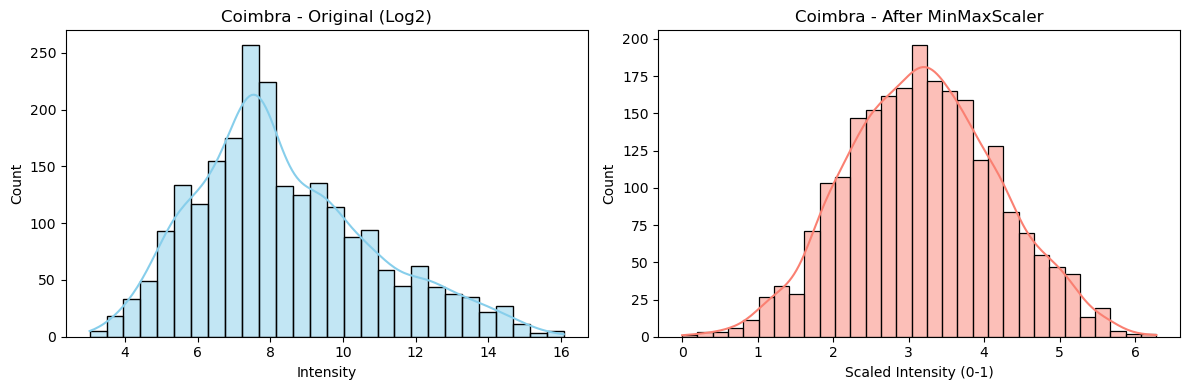

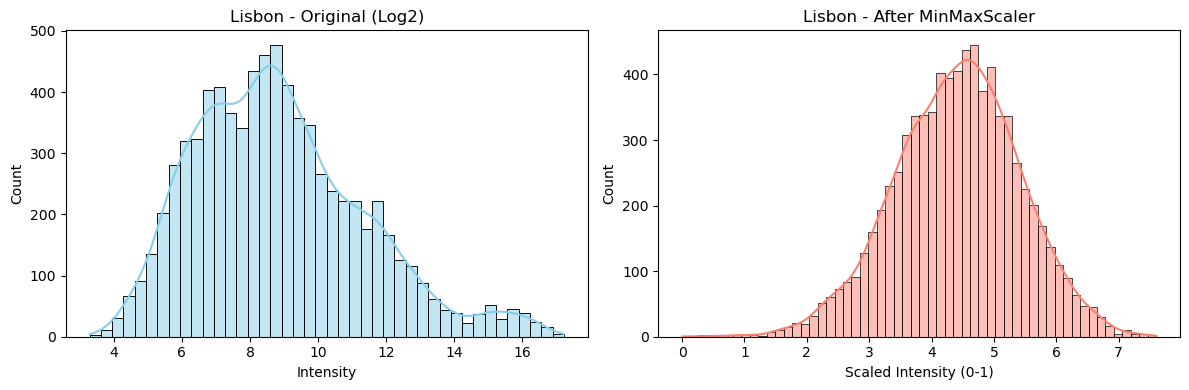

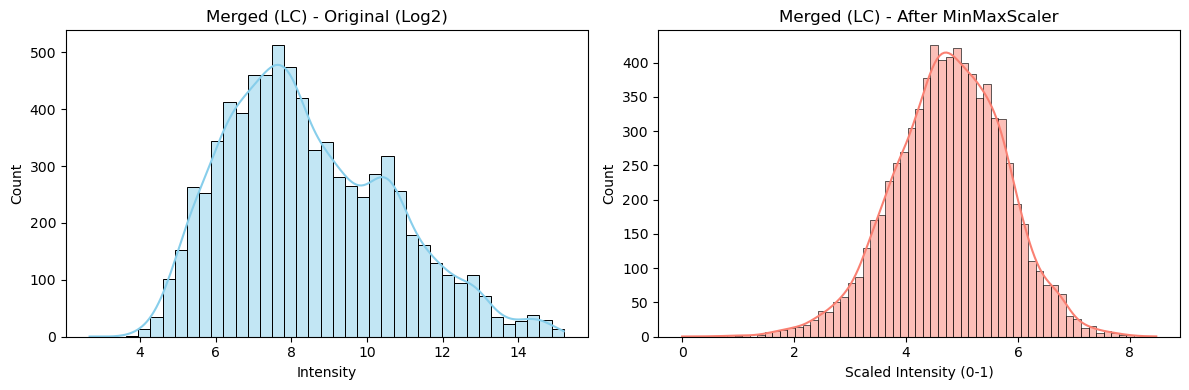

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution_comparison(original, scaled, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribuzione Log2 originale
    sns.histplot(original.values.flatten(), kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'{title} - Original (Log2)')
    ax[0].set_xlabel('Intensity')
    
    # Distribuzione dopo MinMaxScaler
    sns.histplot(scaled.flatten(), kde=True, ax=ax[1], color='salmon')
    ax[1].set_title(f'{title} - After MinMaxScaler')
    ax[1].set_xlabel('Scaled Intensity (0-1)')
    
    plt.tight_layout()
    plt.savefig('plot_distribution_comparison')
    plt.show()

# Esecuzione per i tre dataset
plot_distribution_comparison(filtered_data_Coimbra, X_pos_Coimbra, "Coimbra")
plot_distribution_comparison(filtered_data_Lisbon, X_pos_Lisbon, "Lisbon")
plot_distribution_comparison(filtered_data_LC, X_pos_LC, "Merged (LC)")

In [11]:
import numpy as np
from sklearn.decomposition import NMF
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist

NMF multipla

Esecuzione della NMF più volte con inizializzazioni diverse.
Per ogni run vengono salvati cluster e errore di ricostruzione, selezionando infine il modello con errore minimo.

In [12]:
def run_nmf_multiple(X, k, n_runs=60):
    labels_list = []
    errors = []
    models = []

    for seed in range(n_runs):
        nmf = NMF(
            n_components=k,
            init='random',
            max_iter=10000,
            random_state=seed
        )
        
        W = nmf.fit_transform(X)
        labels = np.argmax(W, axis=1)
        
        labels_list.append(labels)
        errors.append(nmf.reconstruction_err_)
        models.append(nmf)
    
    return np.array(labels_list), np.array(errors), models
    labels_list, errors, models = run_nmf_multiple(X_pos_Coimbra, k)
    
    # scegli la run migliore
    best_idx = np.argmin(errors)
    best_model = models[best_idx]
    
    H = best_model.components_

Consensus matrix

Calcolo della consensus matrix, che misura quanto frequentemente due campioni vengono assegnati allo stesso cluster nelle diverse run di NMF.

In [13]:
def compute_consensus_matrix(labels_list):
    n_runs, n_samples = labels_list.shape
    consensus = np.zeros((n_samples, n_samples))

    for labels in labels_list:
        for i in range(n_samples):
            for j in range(n_samples):
                if labels[i] == labels[j]:
                    consensus[i, j] += 1

    consensus /= n_runs
    return consensus

Cophenetic coefficient

Calcolo del coefficiente cophenetic sulla consensus matrix per valutare la stabilità dei cluster.

In [14]:
def compute_cophenetic(consensus):
    # distanza = 1 - consenso
    distance = 1 - consensus
    
    # condensed distance matrix
    dist_vec = pdist(distance)
    
    linkage_matrix = linkage(dist_vec, method='average')
    
    coph_corr, _ = cophenet(linkage_matrix, dist_vec)
    return coph_corr

Silhouette score

Calcolo del silhouette score per valutare la qualità dei cluster, confrontandolo anche con un baseline casuale.

In [15]:
def compute_silhouette(X, labels):
    return silhouette_score(X, labels)

def compute_random_silhouette(X, k):
    random_labels = np.random.randint(0, k, size=X.shape[0])
    return silhouette_score(X, random_labels)

 Pipeline NMF e stabilità
Esecuzione della pipeline NMF su diversi valori di k, con:


selezione del modello migliore


identificazione delle feature più importanti


valutazione della stabilità (consensus, cophenetic, silhouette)


Vengono inoltre calcolate metriche riassuntive e confronti con baseline random per valutare la qualità dei risultati.


In [16]:
def nmf_stability_pipeline(X, k_range, feature_names=None, n_runs=60):
    results = {}

    for k in k_range:
        print(f"Running k={k}...")

        labels_list, errors, models = run_nmf_multiple(X, k, n_runs)

        best_idx = np.argmin(errors)
        best_model = models[best_idx]
        H = best_model.components_

        W = best_model.transform(X)

        labels = np.argmax(W, axis=1)

        # feature names
        if feature_names is None:
            feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

        # 🔬 top features
        for comp in range(H.shape[0]):
            print(f"\n--- Component {comp} ---")
            top_idx = np.argsort(H[comp])[::-1][:5]
            for i in top_idx:
                print(feature_names[i], H[comp][i])

        # 👥 pazienti per cluster
        print("\n--- Patients per cluster ---")
        for cluster in range(k):
            patients = X.index[labels == cluster]
            print(f"\nCluster {cluster}:")
            print(patients)

        # 📊 metriche
        consensus = compute_consensus_matrix(labels_list)
        cophenetic = compute_cophenetic(consensus)

        sil_real = np.mean([
            compute_silhouette(X, lbls)
            for lbls in labels_list
        ])
        sil_random = compute_random_silhouette(X, k)

        results[k] = {
            "cophenetic": cophenetic,
            "silhouette": sil_real,
            "silhouette_random": sil_random,
            "gap": sil_real - sil_random,
            "error_mean": np.mean(errors),
            "error_std": np.std(errors)
        }

    # =========================
    # POST-PROCESSING
    # =========================

    df_results = pd.DataFrame(results).T
    df_results.index.name = "k"
    df_results = df_results.sort_index()

    err = df_results["error_mean"].values
    err_norm = (err - err.min()) / (err.max() - err.min())

    # 🔹 variance explained
    df_results["delta_error"] = df_results["error_mean"].shift(1) - df_results["error_mean"]
    df_results["perc_variance_explained"] = df_results["delta_error"] / df_results["error_mean"].shift(1)

    # 🔹 random baseline (FIX robusto)
    n_random = 30  # numero di dataset random
    
    random_errors = {}
    
    for k_val in df_results.index:
        rand_errs = []
    
        for _ in range(n_random):
            # nuova randomizzazione ogni volta
            X_random = X.apply(np.random.permutation)
    
            # puoi anche aumentare le run se vuoi
            _, errors_rand, _ = run_nmf_multiple(X_random, k_val, n_runs=5)
    
            rand_errs.append(np.mean(errors_rand))
    
        random_errors[k_val] = np.mean(rand_errs)

    df_results["random_error"] = pd.Series(random_errors)

    # 🔹 random variance
    df_results["delta_error_random"] = df_results["random_error"].shift(1) - df_results["random_error"]
    df_results["perc_variance_random"] = df_results["delta_error_random"] / df_results["random_error"].shift(1)

    # 🔹 fold improvement
    df_results["fold_improvement"] = (
        df_results["perc_variance_explained"] / df_results["perc_variance_random"]
    )

    df_results = df_results.round(4)

    return df_results

In [17]:
def nmf_stability_pipeline_LC(X, k_range, feature_names=None, n_runs=30):
    results = {}

    for k in k_range:
        print(f"Running k={k}...")

        labels_list, errors, models = run_nmf_multiple(X, k, n_runs)
        print("\n" + "="*30)
        print(f"RESULTS FOR k = {k}")
        print("="*30)
        
        best_idx = np.argmin(errors)
        best_model = models[best_idx]
        H = best_model.components_
        
        # embedding UMAP
        umap = UMAP(n_components=2, random_state= 42, n_neighbors=10, min_dist=0.05)
        W = best_model.transform(X)
        X_2d = umap.fit_transform(W)
        # identifica dataset dai nomi pazienti
        patient_ids = LC_df.index.astype(str)
        
        dataset_labels = np.where(
            patient_ids.str.startswith("LIS"),
            "Lisbon",
            "Coimbra"
        )
        
        # cluster da NMF
        W = best_model.transform(X)
        labels = np.argmax(W, axis=1)
        
        # plot
        plt.figure(figsize=(6,5))
        
        for dataset in ["Coimbra", "Lisbon"]:
            pts = X_2d[dataset_labels == dataset]
            plt.scatter(pts[:, 0], pts[:, 1], label=dataset)
        
        plt.title(f'NMF subtypes (k={k})')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        
        plt.legend()
        plt.show()
        
        if feature_names is None:
            feature_names = [f"Feature_{i}" for i in range(X.shape[1])]
        
        for comp in range(H.shape[0]):
            print(f"\n--- Component {comp} ---")
            
            top_idx = np.argsort(H[comp])[::-1][:5]
            
            for i in top_idx:
                print(feature_names[i], H[comp][i])
        # pazienti per cluster
        W = best_model.transform(X)   # ricava W dalla best run
        labels = np.argmax(W, axis=1)
        
        print("\n--- Patients per cluster ---")
        
        for cluster in range(k):
            patients = np.where(labels == cluster)[0]
            print(f"\nCluster {cluster}:")
            print(patients)
        
        consensus = compute_consensus_matrix(labels_list)
        cophenetic = compute_cophenetic(consensus)

        # silhouette 
        sil_real = np.mean([
            compute_silhouette(X, lbls)
            for lbls in labels_list
        ])
        sil_random = compute_random_silhouette(X, k)

        results[k] = {
            "cophenetic": cophenetic,
            "silhouette": sil_real,
            "silhouette_random": sil_random,
            "gap": sil_real - sil_random,
            "error_mean": np.mean(errors),
            "error_std": np.std(errors)
        }
    df_results = pd.DataFrame(results).T
    df_results.index.name = "k"
    df_results = df_results.sort_index()
    
    # 🔹 1. % additional variance explained
    df_results["delta_error"] = df_results["error_mean"].shift(1) - df_results["error_mean"]
    df_results["perc_variance_explained"] = df_results["delta_error"] / df_results["error_mean"].shift(1)
    
    # 🔹 2. RANDOM BASELINE (error)
    random_errors = {}
    
    for k in df_results.index:
        X_random = X.copy()
        X_random = X_random.apply(np.random.permutation)  # shuffle per colonna
        
        _, errors_rand, _ = run_nmf_multiple(X_random, k, n_runs=10)
        random_errors[k] = np.mean(errors_rand)
    
    df_results["random_error"] = pd.Series(random_errors)
    
    # 🔹 3. random variance explained
    df_results["delta_error_random"] = df_results["random_error"].shift(1) - df_results["random_error"]
    df_results["perc_variance_random"] = df_results["delta_error_random"] / df_results["random_error"].shift(1)
    
    # 🔹 4. fold improvement
    df_results["fold_improvement"] = (
        df_results["perc_variance_explained"] / df_results["perc_variance_random"]
    )
    
    # pulizia
    df_results = df_results.round(4)


    return df_results

In [18]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

# 1. Calcolo dell'errore per k=1 (Baseline)
# X deve essere la stessa matrice usata nella pipeline (es. Coimbra_df)
X_values = Coimbra_df.values
nmf_1 = NMF(n_components=1, init='random', random_state=42, max_iter=1000)
nmf_1.fit(X_values)
error_k1 = nmf_1.reconstruction_err_

# 2. Calcolo dell'errore RANDOM per k=1
# Serve per poter calcolare il Fold Improvement di k=2
rand_errs_k1 = []
for _ in range(10): # Bastano poche run per k=1
    X_rand = Coimbra_df.apply(np.random.permutation).values
    nmf_r1 = NMF(n_components=1, init='random', random_state=42, max_iter=1000)
    nmf_r1.fit(X_rand)
    rand_errs_k1.append(nmf_r1.reconstruction_err_)
random_error_k1 = np.mean(rand_errs_k1)

# 3. Aggiornamento dei risultati
df_full = results.copy()
df_full.loc[1, 'error_mean'] = error_k1
df_full.loc[1, 'random_error'] = random_error_k1
df_full = df_full.sort_index()

# 4. Ricalcolo delle metriche di miglioramento
df_full["delta_error"] = df_full["error_mean"].shift(1) - df_full["error_mean"]
df_full["perc_variance_explained"] = df_full["delta_error"] / df_full["error_mean"].shift(1)

df_full["delta_error_random"] = df_full["random_error"].shift(1) - df_full["random_error"]
df_full["perc_variance_random"] = df_full["delta_error_random"] / df_full["random_error"].shift(1)

df_full["fold_improvement"] = df_full["perc_variance_explained"] / df_full["perc_variance_random"]

# 5. GRAFICI SEPARATI (Ora con k=2 incluso!)
ks_full = df_full.index

# Grafico Fold Improvement
plt.figure(figsize=(6,4))
# Il punto k=1 sarà NaN, quindi plotta da k=2 in poi
plt.plot(ks_full, df_full["fold_improvement"], marker='o', color='red', linewidth=2)
plt.axhline(1, color='black', linestyle='--')
plt.title("Fold Improvement (Incluso k=2)")
plt.xlabel("k")
plt.ylabel("Fold Improvement")
plt.grid(True, alpha=0.3)
plt.show()

# Grafico Marginal Gain
plt.figure(figsize=(6,4))
plt.plot(ks_full, df_full["perc_variance_explained"], marker='v', color='green', linewidth=2)
plt.title("Marginal Information Gain (Incluso k=2)")
plt.xlabel("k")
plt.ylabel("% Variance Explained")
plt.grid(True, alpha=0.3)
plt.show()
'''

'\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom sklearn.decomposition import NMF\n\n# 1. Calcolo dell\'errore per k=1 (Baseline)\n# X deve essere la stessa matrice usata nella pipeline (es. Coimbra_df)\nX_values = Coimbra_df.values\nnmf_1 = NMF(n_components=1, init=\'random\', random_state=42, max_iter=1000)\nnmf_1.fit(X_values)\nerror_k1 = nmf_1.reconstruction_err_\n\n# 2. Calcolo dell\'errore RANDOM per k=1\n# Serve per poter calcolare il Fold Improvement di k=2\nrand_errs_k1 = []\nfor _ in range(10): # Bastano poche run per k=1\n    X_rand = Coimbra_df.apply(np.random.permutation).values\n    nmf_r1 = NMF(n_components=1, init=\'random\', random_state=42, max_iter=1000)\n    nmf_r1.fit(X_rand)\n    rand_errs_k1.append(nmf_r1.reconstruction_err_)\nrandom_error_k1 = np.mean(rand_errs_k1)\n\n# 3. Aggiornamento dei risultati\ndf_full = results.copy()\ndf_full.loc[1, \'error_mean\'] = error_k1\ndf_full.loc[1, \'random_error\'] = random_error_k1\ndf_full =

Running k=2...

--- Component 0 ---
P04217 2.0006614977501136
P02753 1.9718901562019457
P02774 1.9630745081389283
P02765 1.9618105933663188
P02760 1.956140276465215

--- Component 1 ---
O00533 2.6512116131350694
Q9Y4C0 2.60591329597881
O94856 2.55794485257714
Q7Z3B1 2.551530262750188
P78324 2.5218093123906384

--- Patients per cluster ---

Cluster 0:
Index(['103698', '107702', '106022', '101960', '104804', '100111', '104726',
       '105438', '105080', '109901', '109089', '102357', '107362', '109522'],
      dtype='object')

Cluster 1:
Index(['108726', '105728', '100855', '106746', '103423', '100112'], dtype='object')
Running k=3...

--- Component 0 ---
Q92520 2.0766952313674882
P02750 1.8800572769190906
Q14118 1.7815369426142837
P02647 1.7797597477127336
Q9UKI9;P09086;P14859 1.7658061800369582

--- Component 1 ---
Q16270 1.7458824725578395
Q13822 1.717449206600474
Q15113 1.660765500130357
P02787 1.6527446642775596
P07585 1.6522921339903325

--- Component 2 ---
O00533 1.844978862922096

/opt/conda/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 10000 reached. Increase it to improve convergence.
  warnings.warn(


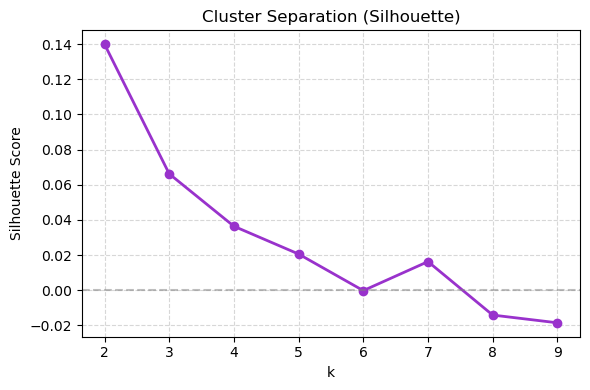

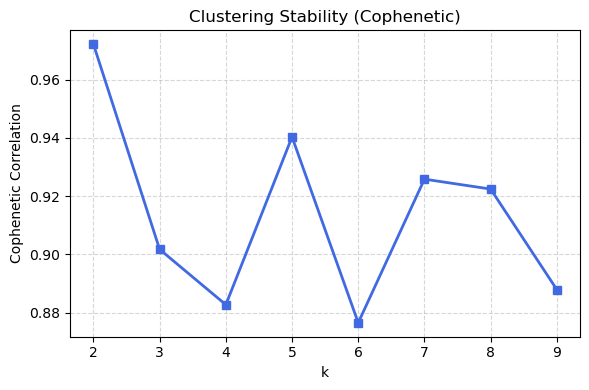

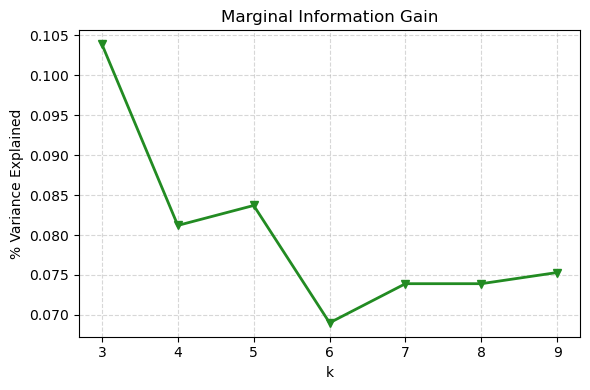

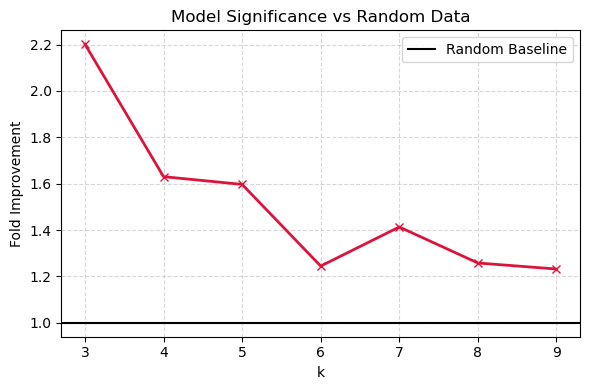

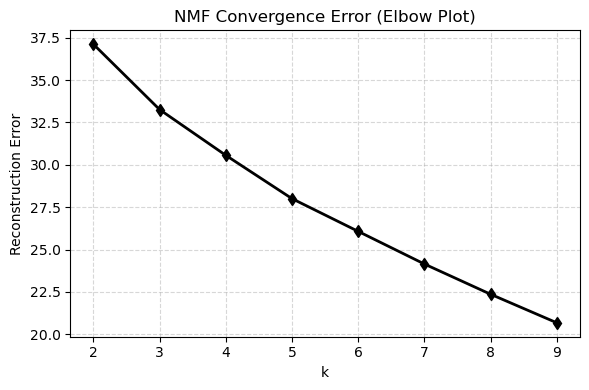

In [19]:
k_range = range(2, 10)

results = nmf_stability_pipeline(Coimbra_df, k_range,feature_names = proteins_present_Coimbra, n_runs=60)
import matplotlib.pyplot as plt

# Definiamo i dati dai tuoi risultati
ks = results.index

# 1. SILHOUETTE SCORE (Separazione dei cluster)
# Valori da -1 a +1. In biologia/omica, sopra 0.2 è spesso già un buon segnale.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["silhouette"], marker='o', color='darkorchid', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5) 
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Cluster Separation (Silhouette)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Silhouette_Score_Coimbra')
plt.show()

# 2. COPHENETIC CORRELATION (Stabilità del Clustering)
# Misura quanto il clustering è robusto attraverso le 60 run.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["cophenetic"], marker='s', color='royalblue', linewidth=2)
plt.xlabel("k")
plt.ylabel("Cophenetic Correlation")
plt.title("Clustering Stability (Cophenetic)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Cophenetic_Correlation_Coimbra')
plt.show()

# 3. % VARIANCE EXPLAINED (Guadagno Marginale)
# Qui cerchi il "gomito": dove la curva spiana, aggiungere k non serve più.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["perc_variance_explained"], marker='v', color='forestgreen', linewidth=2)
plt.xlabel("k")
plt.ylabel("% Variance Explained")
plt.title("Marginal Information Gain")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Marginal_information_gain_Coimbra')
plt.show()

# 4. FOLD IMPROVEMENT (Significatività rispetto al Random)
# Se è vicino a 1, stai modellando rumore casuale. Più è alto, meglio è.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["fold_improvement"], marker='x', color='crimson', linewidth=2)
plt.axhline(1, color='black', linestyle='-', label="Random Baseline")
plt.xlabel("k")
plt.ylabel("Fold Improvement")
plt.title("Model Significance vs Random Data")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Model_Significance_vs_Random_Data_Coimbra')
plt.show()

# 5. RECONSTRUCTION ERROR (Errore Assoluto)
# Classico Elbow Plot.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["error_mean"], marker='d', color='black', linewidth=2)
plt.xlabel("k")
plt.ylabel("Reconstruction Error")
plt.title("NMF Convergence Error (Elbow Plot)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('NMF_converge_error_Coimbra')
plt.show()

In [20]:
results

,cophenetic,silhouette,silhouette_random,gap,error_mean,error_std,delta_error,perc_variance_explained,random_error,delta_error_random,perc_variance_random,fold_improvement
k,,,,,,,,,,,,
2,0.9721,0.1399,0.0308,0.1091,37.1190,0.0000,NaN,NaN,45.3940,NaN,NaN,NaN
3,0.9017,0.0662,-0.0200,0.0862,33.2614,0.0013,3.8577,0.1039,43.2509,2.1431,0.0472,2.2014
4,0.8827,0.0364,-0.0841,0.1205,30.5613,0.0021,2.7001,0.0812,41.0974,2.1536,0.0498,1.6303
5,0.9403,0.0206,-0.0999,0.1205,28.0039,0.0113,2.5574,0.0837,38.9438,2.1536,0.0524,1.5969
6,0.8765,-0.0002,-0.0887,0.0885,26.0706,0.0122,1.9333,0.0690,36.7838,2.1600,0.0555,1.2447
7,0.9258,0.0163,-0.0778,0.0941,24.1438,0.0164,1.9268,0.0739,34.8602,1.9236,0.0523,1.4133
8,0.9224,-0.0141,-0.1377,0.1235,22.3592,0.0131,1.7846,0.0739,32.8118,2.0484,0.0588,1.2579
9,0.8879,-0.0185,-0.1105,0.0921,20.6747,0.0267,1.6845,0.0753,30.8053,2.0065,0.0612,1.2320


Running k=2...

--- Component 0 ---
O00533 3.1128999407377935
Q7Z3B1 3.1081142277132208
P54289 3.0907449498459134
P54764 3.0458583804014383
Q92859 2.9431162063376872

--- Component 1 ---
P02790 2.6453899110467987
P02774 2.5790016412600494
P02749 2.5392923523143898
A0A0B4J1X8 2.496099062888567
P05546 2.480118237649737

--- Patients per cluster ---

Cluster 0:
Index(['LIS011', 'LIS001', 'LIS031', 'LIS029', 'LIS035', 'LIS033', 'LIS047',
       'LIS049', 'LIS004', 'LIS058', 'LIS062', 'LIS081', 'LIS084', 'LIS085',
       'LIS088', 'LIS102', '103698', '107702', '108726', '106022', '105728',
       '100855', '106746', '103423', '100112', '100596', '101960', '104804',
       '100111', '109089', '103176', '102357', '107362'],
      dtype='object')

Cluster 1:
Index(['LIS090', 'LIS008', 'LIS005', 'LIS012', 'LIS018', 'LIS024', 'LIS002',
       'LIS013', 'LIS043', 'LIS040', 'LIS051', 'LIS057', 'LIS064', 'LIS068',
       'LIS076', 'LIS027', 'LIS034', 'LIS052', 'LIS061', 'LIS069', 'LIS073',
       '

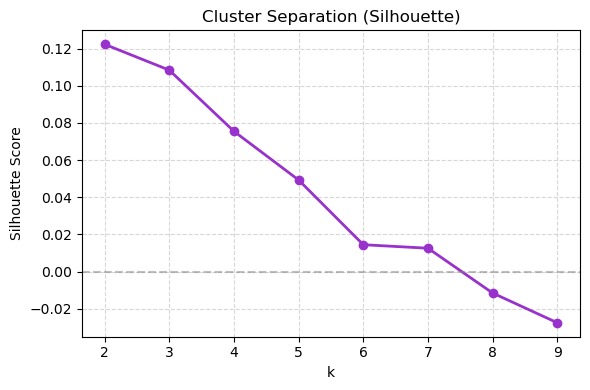

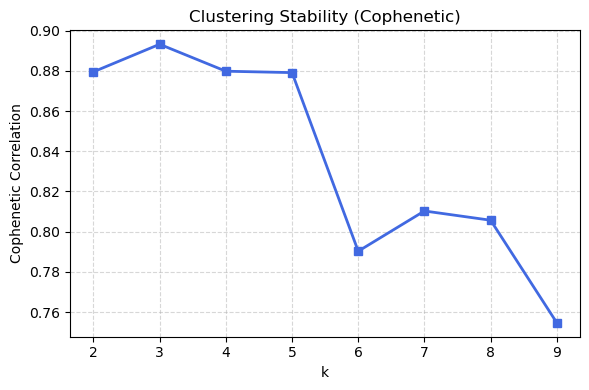

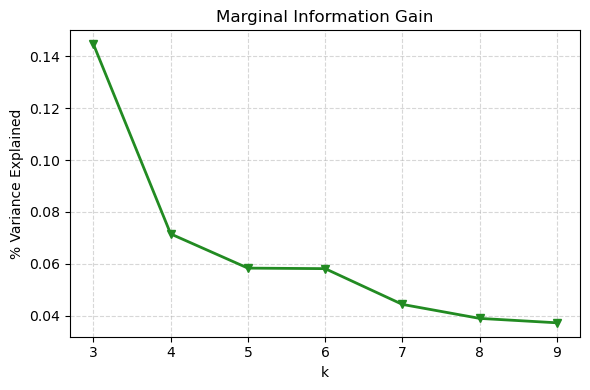

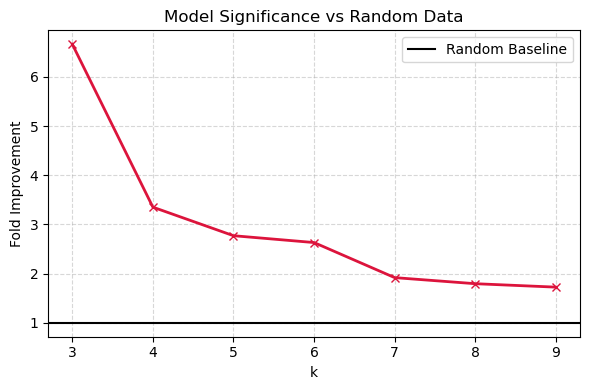

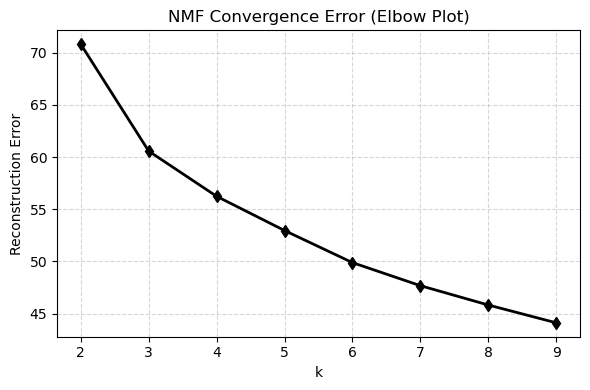

In [21]:
k_range = range(2, 10)

results = nmf_stability_pipeline(LC_df, k_range,feature_names = proteins_present_LC, n_runs=60)
# Definiamo i dati dai tuoi risultati
ks = results.index

# 1. SILHOUETTE SCORE (Separazione dei cluster)
# Valori da -1 a +1. In biologia/omica, sopra 0.2 è spesso già un buon segnale.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["silhouette"], marker='o', color='darkorchid', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5) 
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Cluster Separation (Silhouette)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Silhouette_Score_LC')
plt.show()

# 2. COPHENETIC CORRELATION (Stabilità del Clustering)
# Misura quanto il clustering è robusto attraverso le 60 run.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["cophenetic"], marker='s', color='royalblue', linewidth=2)
plt.xlabel("k")
plt.ylabel("Cophenetic Correlation")
plt.title("Clustering Stability (Cophenetic)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Cophenetic_Correlation_Lisbon')
plt.show()

# 3. % VARIANCE EXPLAINED (Guadagno Marginale)
# Qui cerchi il "gomito": dove la curva spiana, aggiungere k non serve più.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["perc_variance_explained"], marker='v', color='forestgreen', linewidth=2)
plt.xlabel("k")
plt.ylabel("% Variance Explained")
plt.title("Marginal Information Gain")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Marginal_Information_Gain_LC')
plt.show()

# 4. FOLD IMPROVEMENT (Significatività rispetto al Random)
# Se è vicino a 1, stai modellando rumore casuale. Più è alto, meglio è.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["fold_improvement"], marker='x', color='crimson', linewidth=2)
plt.axhline(1, color='black', linestyle='-', label="Random Baseline")
plt.xlabel("k")
plt.ylabel("Fold Improvement")
plt.title("Model Significance vs Random Data")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Model_Significance_vs_Random_Data_LC')
plt.show()

# 5. RECONSTRUCTION ERROR (Errore Assoluto)
# Classico Elbow Plot.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["error_mean"], marker='d', color='black', linewidth=2)
plt.xlabel("k")
plt.ylabel("Reconstruction Error")
plt.title("NMF Convergence Error (Elbow Plot)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Reconstruction_Error_LC')
plt.show()

In [22]:
results

,cophenetic,silhouette,silhouette_random,gap,error_mean,error_std,delta_error,perc_variance_explained,random_error,delta_error_random,perc_variance_random,fold_improvement
k,,,,,,,,,,,,
2,0.8795,0.1223,-0.0042,0.1265,70.8178,0.0000,NaN,NaN,85.0446,NaN,NaN,NaN
3,0.8932,0.1084,-0.0285,0.1369,60.5708,0.0002,10.2470,0.1447,83.1980,1.8466,0.0217,6.6639
4,0.8798,0.0755,-0.0408,0.1164,56.2382,0.0013,4.3326,0.0715,81.4222,1.7758,0.0213,3.3512
5,0.8791,0.0493,-0.0569,0.1062,52.9569,0.0026,3.2813,0.0583,79.7077,1.7145,0.0211,2.7709
6,0.7903,0.0145,-0.0659,0.0804,49.8790,0.0066,3.0779,0.0581,77.9473,1.7604,0.0221,2.6317
7,0.8103,0.0126,-0.0974,0.1100,47.6695,0.0075,2.2094,0.0443,76.1477,1.7996,0.0231,1.9186
8,0.8057,-0.0115,-0.1203,0.1088,45.8150,0.0085,1.8545,0.0389,74.4973,1.6504,0.0217,1.7950
9,0.7547,-0.0275,-0.0977,0.0703,44.1099,0.0095,1.7051,0.0372,72.8902,1.6072,0.0216,1.7251


Running k=2...

--- Component 0 ---
P01008 2.791344866240816
P02790 2.771789394762447
P00747 2.761821325860869
P04217 2.7500690108403485
P01024 2.7364294081515106

--- Component 1 ---
Q9Y4C0 2.4187141573515794
Q92823 2.35441177101168
Q9NTU7 2.3354975344527222
Q15818 2.3230013639963496
P48058 2.3061601832469507

--- Patients per cluster ---

Cluster 0:
Index(['LIS090', 'LIS008', 'LIS012', 'LIS018', 'LIS024', 'LIS013', 'LIS043',
       'LIS040', 'LIS057', 'LIS064', 'LIS068', 'LIS027', 'LIS061', 'LIS069',
       'LIS096', 'LIS097', 'LIS103', 'LIS117'],
      dtype='object')

Cluster 1:
Index(['LIS011', 'LIS001', 'LIS031', 'LIS029', 'LIS005', 'LIS035', 'LIS033',
       'LIS002', 'LIS047', 'LIS051', 'LIS049', 'LIS076', 'LIS004', 'LIS052',
       'LIS058', 'LIS062', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087',
       'LIS088', 'LIS094', 'LIS102'],
      dtype='object')
Running k=3...

--- Component 0 ---
Q9Y4C0 2.5633732835781897
Q92823 2.4846537509045152
Q9ULB1 2.4006320041870777
P1064

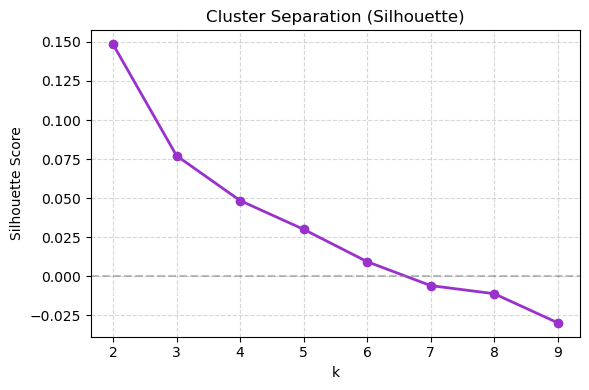

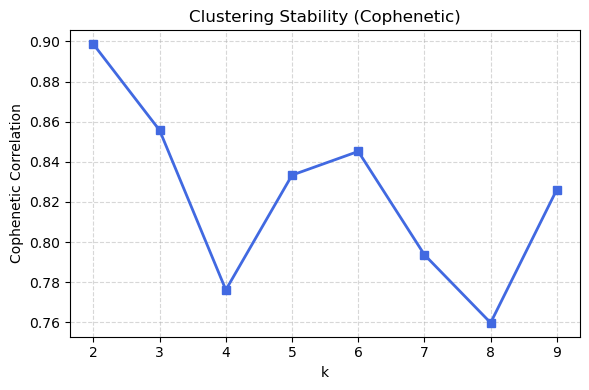

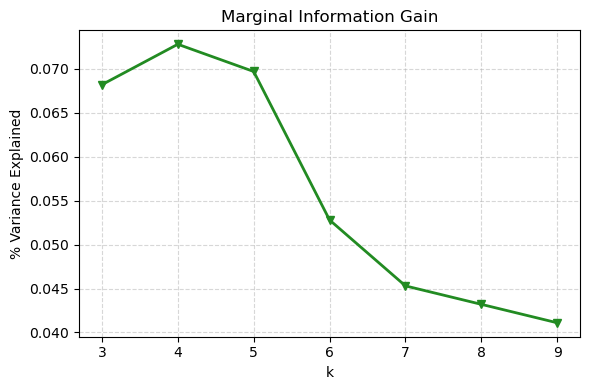

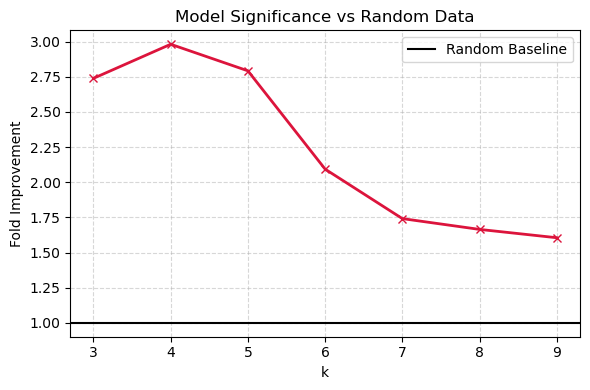

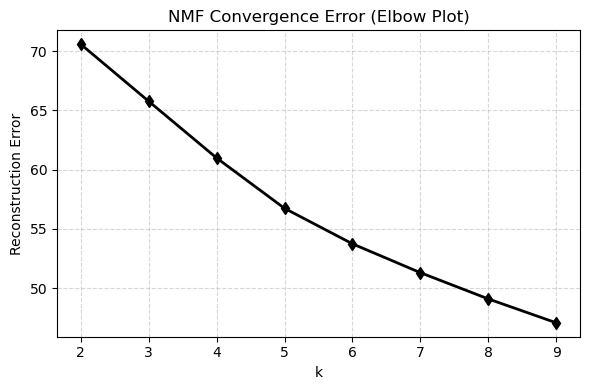

In [23]:
k_range = range(2, 10)

results = nmf_stability_pipeline(Lisbon_df, k_range,feature_names = proteins_present_Lisbon, n_runs=60)
# Definiamo i dati dai tuoi risultati
ks = results.index

# 1. SILHOUETTE SCORE (Separazione dei cluster)
# Valori da -1 a +1. In biologia/omica, sopra 0.2 è spesso già un buon segnale.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["silhouette"], marker='o', color='darkorchid', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5) 
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Cluster Separation (Silhouette)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Silhouette_Score_Lisbon')
plt.show()

# 2. COPHENETIC CORRELATION (Stabilità del Clustering)
# Misura quanto il clustering è robusto attraverso le 60 run.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["cophenetic"], marker='s', color='royalblue', linewidth=2)
plt.xlabel("k")
plt.ylabel("Cophenetic Correlation")
plt.title("Clustering Stability (Cophenetic)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Cophenetic_Correlation_Lisbon')
plt.show()

# 3. % VARIANCE EXPLAINED (Guadagno Marginale)
# Qui cerchi il "gomito": dove la curva spiana, aggiungere k non serve più.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["perc_variance_explained"], marker='v', color='forestgreen', linewidth=2)
plt.xlabel("k")
plt.ylabel("% Variance Explained")
plt.title("Marginal Information Gain")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Marginal_Information_Gain_Lisbon')
plt.show()

# 4. FOLD IMPROVEMENT (Significatività rispetto al Random)
# Se è vicino a 1, stai modellando rumore casuale. Più è alto, meglio è.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["fold_improvement"], marker='x', color='crimson', linewidth=2)
plt.axhline(1, color='black', linestyle='-', label="Random Baseline")
plt.xlabel("k")
plt.ylabel("Fold Improvement")
plt.title("Model Significance vs Random Data")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Model_Significance_vs_Random_Data_Lisbon')
plt.show()

# 5. RECONSTRUCTION ERROR (Errore Assoluto)
# Classico Elbow Plot.
plt.figure(figsize=(6, 4))
plt.plot(ks, results["error_mean"], marker='d', color='black', linewidth=2)
plt.xlabel("k")
plt.ylabel("Reconstruction Error")
plt.title("NMF Convergence Error (Elbow Plot)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('NMF_Convergence_Error_Lisbon')
plt.show()

In [24]:
results

,cophenetic,silhouette,silhouette_random,gap,error_mean,error_std,delta_error,perc_variance_explained,random_error,delta_error_random,perc_variance_random,fold_improvement
k,,,,,,,,,,,,
2,0.8986,0.1485,0.0222,0.1263,70.5928,0.0002,NaN,NaN,85.4486,NaN,NaN,NaN
3,0.8557,0.0772,-0.0173,0.0945,65.7756,0.0002,4.8172,0.0682,83.3202,2.1284,0.0249,2.7395
4,0.7762,0.0485,-0.0384,0.0869,60.9862,0.0010,4.7894,0.0728,81.2857,2.0345,0.0244,2.9820
5,0.8334,0.0301,-0.0501,0.0802,56.7327,0.0051,4.2535,0.0697,79.2558,2.0299,0.0250,2.7929
6,0.8452,0.0094,-0.0949,0.1043,53.7350,0.0070,2.9977,0.0528,77.2553,2.0005,0.0252,2.0934
7,0.7937,-0.0059,-0.0789,0.0729,51.2997,0.0140,2.4354,0.0453,75.2446,2.0108,0.0260,1.7413
8,0.7598,-0.0111,-0.0946,0.0835,49.0822,0.0100,2.2174,0.0432,73.2905,1.9541,0.0260,1.6645
9,0.8262,-0.0297,-0.1046,0.0749,47.0657,0.0163,2.0165,0.0411,71.4147,1.8759,0.0256,1.6052


Modello NMF finale

Addestramento del modello NMF finale con inizializzazione ottimizzata.
Vengono assegnati i cluster, identificate le feature più importanti e i pazienti per ciascun cluster, con visualizzazione opzionale tramite UMAP.

In [25]:
from sklearn.decomposition import NMF
from umap import UMAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def nmf_final_model(X, k, feature_names=None, plot_umap=True, save_path=None):
    print(f"Running FINAL NMF with k={k} (init='nndsvd')")

    model = NMF(
        n_components=k,
        init='nndsvd',
        random_state=0,
        max_iter=10000
    )

    W = model.fit_transform(X)
    H = model.components_

    # cluster assignment
    labels = np.argmax(W, axis=1)

    # =========================
    # 🌌 UMAP (SU W, NON SU X!)
    # =========================
    if plot_umap:
        umap = UMAP(
            n_components=2,
            n_neighbors=10,
            min_dist=0.05,
            random_state=42  # fisso per riproducibilità
        )

        X_2d = umap.fit_transform(W)

        plt.figure(figsize=(6,5))
        for cluster in range(k):
            pts = X_2d[labels == cluster]
            plt.scatter(pts[:, 0], pts[:, 1], label=f'Cluster {cluster}', alpha=0.8)

        plt.title(f'Final NMF (k={k}) - UMAP')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.legend()
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # feature names
    if feature_names is None:
        feature_names = X.columns.tolist()

    # =========================
    # 🔬 TOP FEATURES
    # =========================
    top_features = {}

    for comp in range(k):
        idx = np.argsort(H[comp])[::-1][:30]
        top_features[comp] = [(feature_names[i], H[comp][i]) for i in idx]

        print(f"\n--- Component {comp} ---")
        for f, val in top_features[comp]:
            print(f"{f}: {val:.4f}")

    # =========================
    # 👥 PATIENTS PER CLUSTER
    # =========================
    clusters = {}

    for cluster in range(k):
        patients = X.index[labels == cluster]
        clusters[cluster] = patients

        print(f"\n--- Cluster {cluster} ---")
        print(list(patients))

    return {
        "model": model,
        "W": W,
        "H": H,
        "labels": labels,
        "top_features": top_features,
        "clusters": clusters
    }

In [26]:
from sklearn.decomposition import NMF
from umap import UMAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def nmf_final_model_LC(X, k, feature_names=None, plot_umap=True, save_path=None):
    print(f"Running FINAL NMF with k={k} (init='nndsvd')")

    model = NMF(
        n_components=k,
        init='nndsvd',
        random_state=0,
        max_iter=10000
    )

    W = model.fit_transform(X)
    H = model.components_

    # cluster assignment (lo teniamo comunque)
    labels = np.argmax(W, axis=1)

    # =========================
    # 🌌 UMAP (colorato per DATASET)
    # =========================
    if plot_umap:
        umap = UMAP(
            n_components=2,
            n_neighbors=10,
            min_dist=0.05,
            random_state=42
        )

        X_2d = umap.fit_transform(W)

        # 🔥 identifica dataset dai nomi pazienti
        patient_ids = X.index.astype(str)

        dataset_labels = np.where(
            pd.Series(patient_ids).str.startswith("LIS"),
            "Lisbon",
            "Coimbra"
        )

        plt.figure(figsize=(6,5))

        for dataset in ["Coimbra", "Lisbon"]:
            pts = X_2d[dataset_labels == dataset]
            plt.scatter(
                pts[:, 0],
                pts[:, 1],
                label=dataset,
                alpha=0.8
            )

        plt.title(f'Final NMF (k={k}) - UMAP (Dataset)')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.legend()
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # =========================
    # FEATURE NAMES
    # =========================
    if feature_names is None:
        feature_names = X.columns.tolist()

    # =========================
    # 🔬 TOP FEATURES
    # =========================
    top_features = {}

    for comp in range(k):
        idx = np.argsort(H[comp])[::-1][:10]
        top_features[comp] = [(feature_names[i], H[comp][i]) for i in idx]

        print(f"\n--- Component {comp} ---")
        for f, val in top_features[comp]:
            print(f"{f}: {val:.4f}")

    # =========================
    # 👥 PATIENTS PER CLUSTER
    # =========================
    clusters = {}

    for cluster in range(k):
        patients = X.index[labels == cluster]
        clusters[cluster] = patients

        print(f"\n--- Cluster {cluster} ---")
        print(list(patients))

    return {
        "model": model,
        "W": W,
        "H": H,
        "labels": labels,
        "top_features": top_features,
        "clusters": clusters,
        "dataset_labels": dataset_labels
    }

Running FINAL NMF with k=3 (init='nndsvd')


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


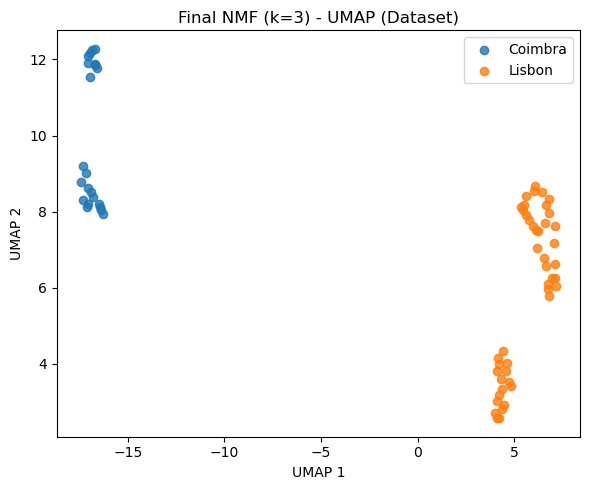


--- Component 0 ---
P02747: 1.8140
P23515: 1.8052
Q12805: 1.8021
P61916: 1.7606
Q99574: 1.7603
P41222: 1.7523
P00736: 1.7276
P04180: 1.7224
P07998: 1.7195
Q96GW7: 1.6045

--- Component 1 ---
Q7Z3B1: 2.0143
O00533: 1.9923
P54289: 1.9826
P54764: 1.9484
Q92859: 1.8391
O14594: 1.8360
P51693: 1.8305
Q9ULB1: 1.8204
Q9UBP4: 1.8019
Q7Z7M0: 1.7806

--- Component 2 ---
P01011: 1.4058
P43652: 1.3611
P02760: 1.3564
P01024: 1.3523
P02765: 1.3370
P04217: 1.3367
P00450: 1.3332
P01042: 1.3305
P07225: 1.3210
P05155: 1.2880

--- Cluster 0 ---
['LIS011', 'LIS001', 'LIS031', 'LIS029', 'LIS002', 'LIS047', 'LIS051', 'LIS057', 'LIS064', 'LIS076', 'LIS004', 'LIS034', 'LIS052', 'LIS058', 'LIS062', 'LIS069', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117']

--- Cluster 1 ---
['LIS035', 'LIS033', 'LIS049', '108726', '105728', '100855', '106746', '103423', '100112', '104804', '100111', '107362']

--- Cluster 2 ---
['LIS090', 'LIS008', 'LIS005', 'LIS012', 'LIS018

{'model': NMF(init='nndsvd', max_iter=10000, n_components=3, random_state=0),
 'W': array([[1.73066417, 1.58248863, 1.82696953],
        [1.84306848, 1.0773864 , 2.97424706],
        [1.99257159, 1.74913012, 1.24093189],
        [1.99471523, 1.75023699, 1.30944867],
        [2.21231292, 2.01656207, 0.58118196],
        [1.88386095, 1.77279182, 1.71381409],
        [1.79567083, 1.58687624, 1.8201069 ],
        [1.80098119, 1.50978104, 2.31135083],
        [1.80887   , 1.33047509, 2.2497364 ],
        [2.06384489, 2.20604857, 0.9215587 ],
        [1.80838682, 2.15680724, 0.84883967],
        [1.88057317, 1.13951269, 2.39349229],
        [1.73931455, 1.38495059, 1.66037978],
        [1.71153912, 1.13423483, 2.2441696 ],
        [1.45925107, 1.63480266, 2.39297277],
        [1.54411083, 1.29287621, 2.5990848 ],
        [1.79093409, 1.78605168, 1.01637095],
        [1.78277649, 1.42942984, 1.64995722],
        [1.86036829, 1.89438586, 1.46936964],
        [2.34457368, 0.88792327, 2.21896918

In [27]:
nmf_final_model_LC(LC_df, k=3, save_path="umap_combined_datasets.png")

Running FINAL NMF with k=3 (init='nndsvd')


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


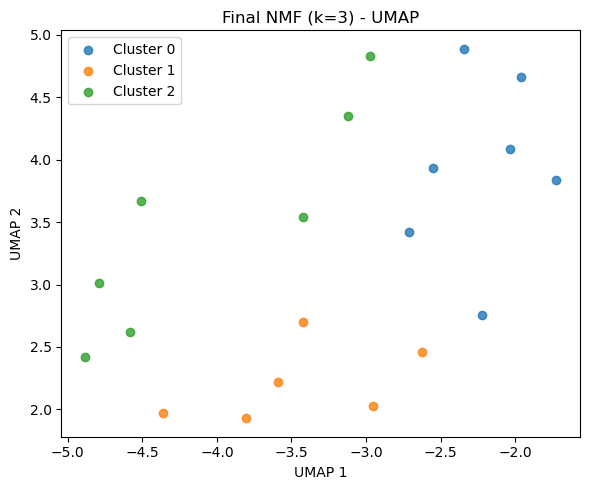


--- Component 0 ---
P02647: 1.2447
P02753: 1.2381
P08697: 1.2259
P01009: 1.2101
P02760: 1.2051
P25311: 1.1997
P04217: 1.1936
P02750: 1.1910
B9A064: 1.1872
P06312: 1.1834
A0A075B6K5: 1.1770
P51884: 1.1714
P0DOY2;P0DOY3: 1.1704
P27169: 1.1645
P01042: 1.1602
P02765: 1.1557
P01834: 1.1390
P05156: 1.1331
P06727: 1.1250
P02774: 1.0922
P04196: 1.0863
P02790: 1.0585
P05546: 1.0551
P05155: 1.0473
P01876: 1.0373
Q9UKI9;P09086;P14859: 1.0332
P05090: 1.0324
P00734: 1.0250
P22352: 0.9896
P01859: 0.9823

--- Component 1 ---
Q7Z3B1: 1.2492
Q9Y4C0: 1.2469
O94856: 1.2017
O00533: 1.1799
Q92823: 1.1336
Q14982: 1.1292
P78324: 1.1279
P05067: 1.1239
P49641: 1.0841
P54764: 1.0660
P04216: 1.0594
Q92859: 1.0534
P13591: 1.0503
Q9ULB1: 1.0404
Q9UBP4: 0.9928
Q7Z7M0: 0.9920
Q92520: 0.9767
P60174: 0.9160
P13473: 0.8925
P14618: 0.8833
O15394: 0.8768
P12109: 0.8709
Q14118: 0.7986
P33908: 0.7777
Q8N126: 0.7615
Q12860: 0.7503
Q9NQ79: 0.7447
Q53EL9: 0.7445
O43790;P78385;Q14533;P78386: 0.7332
P19021: 0.7243

--- Compone

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


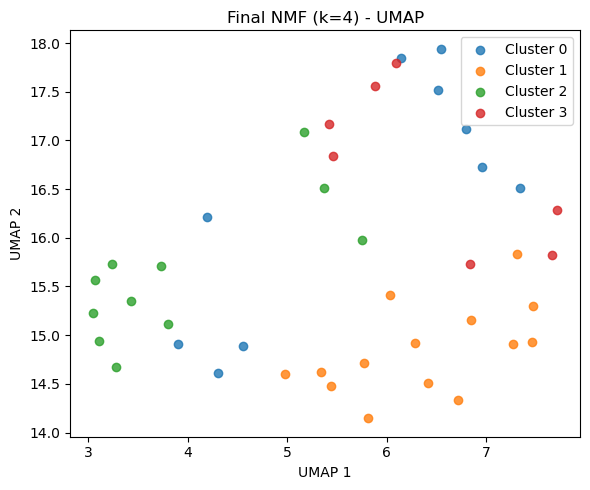


--- Component 0 ---
P19827: 1.7945
P01031: 1.7415
P19823: 1.7411
P02765: 1.6739
P29622: 1.6592
Q14624: 1.6553
P27169: 1.5775
P04004: 1.5697
P43652: 1.5602
P35858: 1.5589
P02763: 1.5586
P00747: 1.5575
P08185: 1.5333
Q96IY4: 1.5320
P01008: 1.5154
P01042: 1.5108
P19652: 1.4968
P04217: 1.4899
P00751: 1.4858
P02647: 1.4776
P06727: 1.4581
A0A0C4DH38: 1.4394
P00450: 1.4389
P01024: 1.4377
P05154: 1.4285
P00740: 1.4071
P01871: 1.4051
P07357: 1.4005
P05546: 1.3910
P08697: 1.3853

--- Component 1 ---
Q9Y4C0: 1.5566
Q92823: 1.5010
Q9NTU7: 1.4514
P54289: 1.4299
P48058: 1.4282
O00533: 1.4158
Q9ULB1: 1.4143
Q9P2S2: 1.4143
P51693: 1.4103
Q15818: 1.4096
P54764: 1.4010
P04216: 1.3902
P10645: 1.3882
Q86UN3: 1.3791
Q8WZA1: 1.3560
O95502: 1.3541
O14594: 1.3539
P04406: 1.3493
P17174: 1.3451
Q9NT99: 1.3440
P04075: 1.3374
Q6UXD5: 1.3370
Q9NQ79: 1.3262
O94856: 1.3166
P19021: 1.3159
P05067: 1.3078
Q7Z3B1: 1.3029
Q99435: 1.3000
P40925: 1.2928
P07195: 1.2690

--- Component 2 ---
P02766: 1.1340
P18065: 1.1102
P08

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


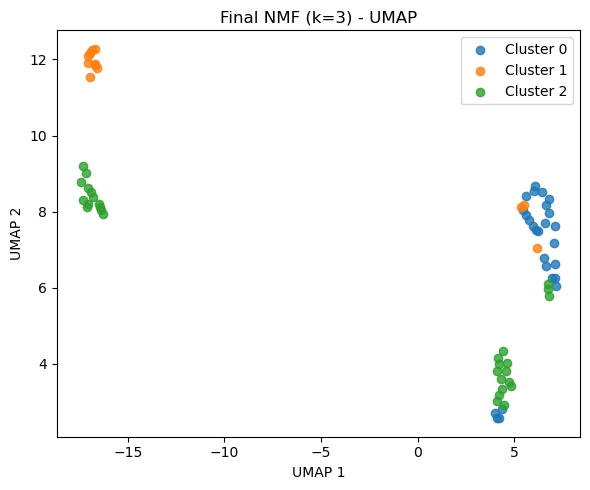


--- Component 0 ---
P02747: 1.8140
P23515: 1.8052
Q12805: 1.8021
P61916: 1.7606
Q99574: 1.7603
P41222: 1.7523
P00736: 1.7276
P04180: 1.7224
P07998: 1.7195
Q96GW7: 1.6045
P02749: 1.5948
P02746: 1.5925
P01034: 1.5805
O75326: 1.5787
P04216: 1.5787
P23142: 1.5761
P02790: 1.5239
A0A0B4J1X8: 1.5068
P01861: 1.4894
P02753: 1.4770
P16070: 1.4513
A0A0A0MS15: 1.4295
P05546: 1.4266
P02774: 1.4155
Q9NRN5: 1.4145
Q6MZW2: 1.3547
P02647: 1.3317
P14618: 1.3312
P06396: 1.3307
Q9NQ79: 1.3297

--- Component 1 ---
Q7Z3B1: 2.0143
O00533: 1.9923
P54289: 1.9826
P54764: 1.9484
Q92859: 1.8391
O14594: 1.8360
P51693: 1.8305
Q9ULB1: 1.8204
Q9UBP4: 1.8019
Q7Z7M0: 1.7806
P05060: 1.7303
Q14982: 1.7114
Q9P121: 1.7061
P33908: 1.6992
P05067: 1.6763
P43121: 1.6596
Q9Y4C0: 1.6471
P40925: 1.6398
O43505: 1.6188
P17174: 1.6062
P06733: 1.6045
Q14118: 1.5909
Q6MZW2: 1.5420
Q92520: 1.5395
Q9NT99: 1.5245
Q15818: 1.5151
Q12860: 1.5022
Q14515: 1.4587
P07195: 1.4493
P12109: 1.4087

--- Component 2 ---
P01011: 1.4058
P43652: 1.3611

In [30]:
results_fin_Coimbra = nmf_final_model(Coimbra_df, k=3, save_path="umap_coimbra.png")
results_fin_Lisbon = nmf_final_model(Lisbon_df, k=4, save_path="umap_lisbon.png")
results_fin_LC = nmf_final_model(LC_df, k=3, save_path="umap_combined.png")

In [31]:
labels_Coimbra = results_fin_Coimbra['labels']
top_features_NMF_Coimbra = results_fin_Coimbra['top_features']
cluster_series_Coimbra = pd.Series(labels_Coimbra, index=Coimbra_df.index, name="cluster")

In [ ]:
cluster_series_Coimbra

In [32]:
labels_LC = results_fin_LC['labels']
cluster_series_LC = pd.Series(labels_LC, index=LC_df.index, name="cluster")

In [ ]:
cluster_series_LC

In [33]:
labels_Lisbon = results_fin_Lisbon['labels']
top_features_NMF_Lisbon = results_fin_Lisbon['top_features']
cluster_series_Lisbon = pd.Series(labels_Lisbon, index=Lisbon_df.index, name="cluster")

In [ ]:
cluster_series_Lisbon

In [34]:
proteins = [f for f, _ in results_fin_LC["top_features"][2]]
for i in proteins:
    print(i)

P01011
P43652
P02760
P01024
P02765
P04217
P00450
P01042
P07225
P05155
P02774
P02763
P02790
P27169
P09871
P02750
P05156
P01033
P07585
P36955
Q13822
P05546
P06396
P0C0L4
P20774
P06727
P02647
P08123
P16035
P25311


In [35]:
follow_dict = dict(zip(follow_up["Code"], follow_up["tempo follow-up"]))

In [36]:
follow_up_values_Lisbon = filtered_data_Lisbon.index.map(follow_dict)

In [ ]:
follow_dict

In [39]:
follow_up["Code"] = follow_up["Code"].astype(str)
filtered_data_Coimbra.index = filtered_data_Coimbra.index.astype(str)
follow_dict = dict(zip(
    follow_up["Code"],
    follow_up["tempo follow-up"]
))

In [40]:
follow_up_values_Coimbra = filtered_data_Coimbra.index.map(follow_dict)

print(follow_up_values_Coimbra.isna().sum())
print(len(follow_up_values_Coimbra))

3
20


In [41]:
follow_up["Code"] = follow_up["Code"].astype(str).str.strip()
filtered_data_LC.index = filtered_data_LC.index.astype(str).str.strip()
follow_dict = dict(zip(
    follow_up["Code"],
    follow_up["tempo follow-up"]
))
follow_up_values_LC = filtered_data_LC.index.map(follow_dict)
print("NaN:", follow_up_values_LC.isna().sum())
print("Tot:", len(follow_up_values_LC))

NaN: 12
Tot: 67


In [42]:
from sklearn.decomposition import NMF
from umap import UMAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def nmf_final_model_follow_up(X, k, feature_names=None, plot_umap=True, follow_up_values=None, save_path=None):
    print(f"Running FINAL NMF with k={k} (init='nndsvd')")

    model = NMF(
        n_components=k,
        init='nndsvd',
        random_state=0,
        max_iter=10000
    )

    W = model.fit_transform(X)
    H = model.components_

    # cluster assignment
    labels = np.argmax(W, axis=1)

    # =========================
    # 🌌 UMAP (SU W, NON SU X!)
    # =========================
    if plot_umap:
        umap = UMAP(
            n_components=2,
            n_neighbors=10,
            min_dist=0.05,
            random_state=42
        )
    
        X_2d = umap.fit_transform(W)
    
        plt.figure(figsize=(6,5))
    
        # 🔥 SE hai follow-up → colora per follow-up
        if follow_up_values is not None:
    
            follow_up_values = pd.Series(follow_up_values, index=X.index)
    
            mask_valid = ~follow_up_values.isna()
    
            sc = plt.scatter(
                X_2d[mask_valid, 0],
                X_2d[mask_valid, 1],
                c=follow_up_values[mask_valid],
                cmap="viridis",
                alpha=0.8
            )
    
            # NaN in grigio
            mask_nan = follow_up_values.isna()
            plt.scatter(
                X_2d[mask_nan, 0],
                X_2d[mask_nan, 1],
                color="lightgray",
                alpha=0.5,
                label="No follow-up"
            )
    
            plt.colorbar(sc, label="Tempo follow-up")
    
        # 🔵 ALTRIMENTI comportamento originale (cluster)
        else:
            for cluster in range(k):
                pts = X_2d[labels == cluster]
                plt.scatter(pts[:, 0], pts[:, 1], label=f'Cluster {cluster}', alpha=0.8)
    
            plt.legend()
    
        plt.title(f'Final NMF (k={k}) - UMAP')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    # feature names
    if feature_names is None:
        feature_names = X.columns.tolist()

    # =========================
    # 🔬 TOP FEATURES
    # =========================
    top_features = {}

    for comp in range(k):
        idx = np.argsort(H[comp])[::-1][:30]
        top_features[comp] = [(feature_names[i], H[comp][i]) for i in idx]

        print(f"\n--- Component {comp} ---")
        for f, val in top_features[comp]:
            print(f"{f}: {val:.4f}")

    # =========================
    # 👥 PATIENTS PER CLUSTER
    # =========================
    clusters = {}

    for cluster in range(k):
        patients = X.index[labels == cluster]
        clusters[cluster] = patients

        print(f"\n--- Cluster {cluster} ---")
        print(list(patients))

    return {
        "model": model,
        "W": W,
        "H": H,
        "labels": labels,
        "top_features": top_features,
        "clusters": clusters
    }

Running FINAL NMF with k=3 (init='nndsvd')


/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


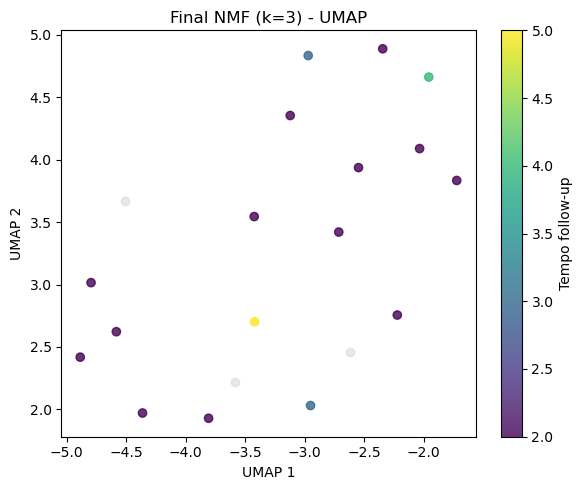


--- Component 0 ---
P02647: 1.2447
P02753: 1.2381
P08697: 1.2259
P01009: 1.2101
P02760: 1.2051
P25311: 1.1997
P04217: 1.1936
P02750: 1.1910
B9A064: 1.1872
P06312: 1.1834
A0A075B6K5: 1.1770
P51884: 1.1714
P0DOY2;P0DOY3: 1.1704
P27169: 1.1645
P01042: 1.1602
P02765: 1.1557
P01834: 1.1390
P05156: 1.1331
P06727: 1.1250
P02774: 1.0922
P04196: 1.0863
P02790: 1.0585
P05546: 1.0551
P05155: 1.0473
P01876: 1.0373
Q9UKI9;P09086;P14859: 1.0332
P05090: 1.0324
P00734: 1.0250
P22352: 0.9896
P01859: 0.9823

--- Component 1 ---
Q7Z3B1: 1.2492
Q9Y4C0: 1.2469
O94856: 1.2017
O00533: 1.1799
Q92823: 1.1336
Q14982: 1.1292
P78324: 1.1279
P05067: 1.1239
P49641: 1.0841
P54764: 1.0660
P04216: 1.0594
Q92859: 1.0534
P13591: 1.0503
Q9ULB1: 1.0404
Q9UBP4: 0.9928
Q7Z7M0: 0.9920
Q92520: 0.9767
P60174: 0.9160
P13473: 0.8925
P14618: 0.8833
O15394: 0.8768
P12109: 0.8709
Q14118: 0.7986
P33908: 0.7777
Q8N126: 0.7615
Q12860: 0.7503
Q9NQ79: 0.7447
Q53EL9: 0.7445
O43790;P78385;Q14533;P78386: 0.7332
P19021: 0.7243

--- Compone

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


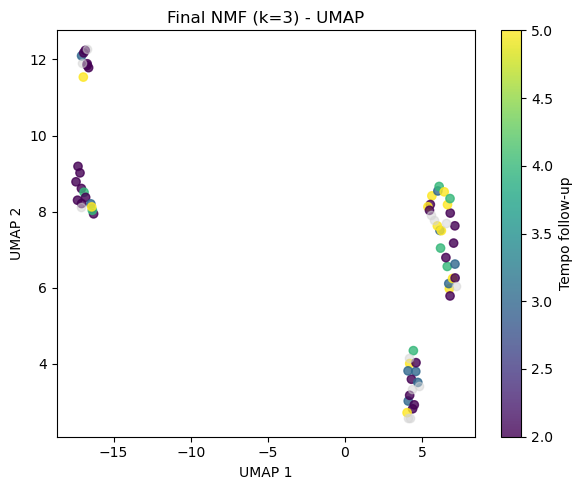


--- Component 0 ---
P02747: 1.8140
P23515: 1.8052
Q12805: 1.8021
P61916: 1.7606
Q99574: 1.7603
P41222: 1.7523
P00736: 1.7276
P04180: 1.7224
P07998: 1.7195
Q96GW7: 1.6045
P02749: 1.5948
P02746: 1.5925
P01034: 1.5805
O75326: 1.5787
P04216: 1.5787
P23142: 1.5761
P02790: 1.5239
A0A0B4J1X8: 1.5068
P01861: 1.4894
P02753: 1.4770
P16070: 1.4513
A0A0A0MS15: 1.4295
P05546: 1.4266
P02774: 1.4155
Q9NRN5: 1.4145
Q6MZW2: 1.3547
P02647: 1.3317
P14618: 1.3312
P06396: 1.3307
Q9NQ79: 1.3297

--- Component 1 ---
Q7Z3B1: 2.0143
O00533: 1.9923
P54289: 1.9826
P54764: 1.9484
Q92859: 1.8391
O14594: 1.8360
P51693: 1.8305
Q9ULB1: 1.8204
Q9UBP4: 1.8019
Q7Z7M0: 1.7806
P05060: 1.7303
Q14982: 1.7114
Q9P121: 1.7061
P33908: 1.6992
P05067: 1.6763
P43121: 1.6596
Q9Y4C0: 1.6471
P40925: 1.6398
O43505: 1.6188
P17174: 1.6062
P06733: 1.6045
Q14118: 1.5909
Q6MZW2: 1.5420
Q92520: 1.5395
Q9NT99: 1.5245
Q15818: 1.5151
Q12860: 1.5022
Q14515: 1.4587
P07195: 1.4493
P12109: 1.4087

--- Component 2 ---
P01011: 1.4058
P43652: 1.3611

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


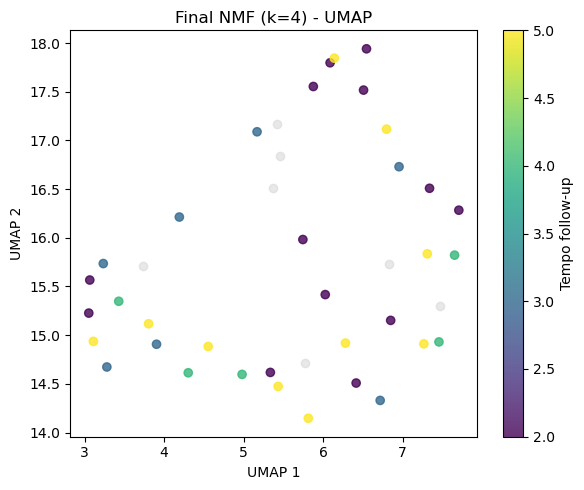


--- Component 0 ---
P19827: 1.7945
P01031: 1.7415
P19823: 1.7411
P02765: 1.6739
P29622: 1.6592
Q14624: 1.6553
P27169: 1.5775
P04004: 1.5697
P43652: 1.5602
P35858: 1.5589
P02763: 1.5586
P00747: 1.5575
P08185: 1.5333
Q96IY4: 1.5320
P01008: 1.5154
P01042: 1.5108
P19652: 1.4968
P04217: 1.4899
P00751: 1.4858
P02647: 1.4776
P06727: 1.4581
A0A0C4DH38: 1.4394
P00450: 1.4389
P01024: 1.4377
P05154: 1.4285
P00740: 1.4071
P01871: 1.4051
P07357: 1.4005
P05546: 1.3910
P08697: 1.3853

--- Component 1 ---
Q9Y4C0: 1.5566
Q92823: 1.5010
Q9NTU7: 1.4514
P54289: 1.4299
P48058: 1.4282
O00533: 1.4158
Q9ULB1: 1.4143
Q9P2S2: 1.4143
P51693: 1.4103
Q15818: 1.4096
P54764: 1.4010
P04216: 1.3902
P10645: 1.3882
Q86UN3: 1.3791
Q8WZA1: 1.3560
O95502: 1.3541
O14594: 1.3539
P04406: 1.3493
P17174: 1.3451
Q9NT99: 1.3440
P04075: 1.3374
Q6UXD5: 1.3370
Q9NQ79: 1.3262
O94856: 1.3166
P19021: 1.3159
P05067: 1.3078
Q7Z3B1: 1.3029
Q99435: 1.3000
P40925: 1.2928
P07195: 1.2690

--- Component 2 ---
P02766: 1.1340
P18065: 1.1102
P08

In [49]:
results_fu_Coi = nmf_final_model_follow_up(
    Coimbra_df,
    k=3,
    follow_up_values=follow_up_values_Coimbra,
    save_path="umap_followup_coimbra.png"
)

results_fu_LC = nmf_final_model_follow_up(
    LC_df,
    k=3,
    follow_up_values=follow_up_values_LC,
    save_path="umap_followup_lisbon.png"
)

results_fu_Lis = nmf_final_model_follow_up(
    Lisbon_df,
    k=4,
    follow_up_values=follow_up_values_Lisbon,
    save_path="umap_followup_lisbon.png"
)

Tabella riassuntiva

Creazione di una tabella per cluster con numero di pazienti e distribuzione percentuale del follow-up.

In [44]:
def summary_table(X, labels, follow_up_values):
    
    df = pd.DataFrame({
        "patient": X.index.astype(str),
        "cluster": labels,
        "follow_up": follow_up_values
    })
    
    summary = []

    for cluster in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == cluster]
        n = len(sub)
        
        # ------------------------
        # FOLLOW-UP %
        # ------------------------
        fu_counts = sub["follow_up"].value_counts(normalize=True) * 100
        
        row = {
            "cluster": cluster,
            "n_patients": n,
        }
        
        # aggiungi follow-up (2–5)
        for fu in [2, 3, 4, 5]:
            row[f"% FU={fu}"] = round(fu_counts.get(fu, 0), 1)
        
        summary.append(row)
    
    summary_df = pd.DataFrame(summary)
    
    return summary_df

In [45]:
def summary_table_LC(X, labels, follow_up_values):
    
    df = pd.DataFrame({
        "patient": X.index.astype(str),
        "cluster": labels,
        "follow_up": follow_up_values
    })
    
    # 🔹 dataset (Lisbon vs Coimbra)
    df["dataset"] = df["patient"].str.startswith("LIS")
    df["dataset"] = df["dataset"].map({True: "Lisbon", False: "Coimbra"})
    
    summary = []

    for cluster in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == cluster]
        n = len(sub)
        
        # ------------------------
        # DATASET %
        # ------------------------
        dataset_counts = sub["dataset"].value_counts(normalize=True) * 100
        
        coimbra_pct = dataset_counts.get("Coimbra", 0)
        lisbon_pct = dataset_counts.get("Lisbon", 0)
        
        # ------------------------
        # FOLLOW-UP %
        # ------------------------
        fu_counts = sub["follow_up"].value_counts(normalize=True) * 100
        
        row = {
            "cluster": cluster,
            "n_patients": n,
            "% Coimbra": round(coimbra_pct, 1),
            "% Lisbon": round(lisbon_pct, 1),
        }
        
        # aggiungi follow-up (2–5)
        for fu in [2, 3, 4, 5]:
            row[f"% FU={fu}"] = round(fu_counts.get(fu, 0), 1)
        
        summary.append(row)
    
    summary_df = pd.DataFrame(summary)
    
    return summary_df

In [50]:
summary_LC = summary_table_LC(
    X=LC_df,
    labels=results_fu_LC["labels"],
    follow_up_values=follow_up_values_LC
)

print(summary_LC)

   cluster  n_patients  % Coimbra  % Lisbon  % FU=2  % FU=3  % FU=4  % FU=5
0        0          26        0.0     100.0    35.0    15.0    15.0    35.0
1        1          12       75.0      25.0    60.0    10.0    10.0    20.0
2        2          29       44.8      55.2    52.0    24.0    12.0    12.0


In [51]:
summary_Lisbon = summary_table(
    X=Lisbon_df,
    labels=results_fu_Lis["labels"],
    follow_up_values=follow_up_values_Lisbon
)

print(summary_Lisbon)

   cluster  n_patients  % FU=2  % FU=3  % FU=4  % FU=5
0        0          10    30.0    30.0    10.0    30.0
1        1          14    33.3     8.3    16.7    41.7
2        2          11    33.3    33.3    11.1    22.2
3        3           7    75.0     0.0    25.0     0.0


In [52]:
summary_Coimbra = summary_table(
    X=Coimbra_df,
    labels=results_fu_Coi["labels"],
    follow_up_values=follow_up_values_Coimbra
)

print(summary_Coimbra)

   cluster  n_patients  % FU=2  % FU=3  % FU=4  % FU=5
0        0           7    85.7     0.0    14.3     0.0
1        1           6    50.0    25.0     0.0    25.0
2        2           7    83.3    16.7     0.0     0.0


Identificazione biomarcatori (Random Forest)

Applicazione di un modello Random Forest in modalità one-vs-rest per identificare le feature più importanti (biomarcatori) per ciascun cluster.

In [53]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

X = Coimbra_df.copy()
y = cluster_series_Coimbra.values

cluster_biomarkers = {}

for cluster in np.unique(y):

    print(f"\n===== CLUSTER {cluster} =====")

    # one-vs-rest
    y_binary = (y == cluster).astype(int)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X, y_binary)

    importance = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    top_features = importance.head(30)

    cluster_biomarkers[cluster] = top_features

    print(top_features)


===== CLUSTER 0 =====
Protein.Group
P02753                  0.050087
P25311                  0.047128
P23142                  0.040414
P01009                  0.039750
P02760                  0.035616
P08697                  0.034818
P04217                  0.028696
P02647                  0.027408
Q5SYB0                  0.026997
A0A075B6K5              0.024993
P01834                  0.024019
P06312                  0.023122
P01876                  0.022791
Q9UKI9;P09086;P14859    0.022733
P27169                  0.021331
P04216                  0.018951
P02749                  0.017820
P00734                  0.016527
O00533                  0.015864
P02750                  0.015244
P04196                  0.013498
P05546                  0.013469
P05067                  0.013383
P22352                  0.011546
P17174                  0.011529
P49641                  0.010473
B9A064                  0.010391
P02765                  0.010279
Q92859                  0.010021
P02774

Confronto biomarcatori (NMF vs Random Forest)

Confronto tra le feature selezionate da NMF e Random Forest per ciascun cluster, calcolando l’overlap e la similarità di Jaccard.

In [54]:
rf_sets = {
    k: set(cluster_biomarkers[k].index)
    for k in cluster_biomarkers
}

nmf_sets = {
    k: set([p[0] for p in top_features_NMF_Coimbra[k]])
    for k in top_features_NMF_Coimbra
}

In [55]:
for k in rf_sets:
    if k not in nmf_sets:
        continue

    rf = rf_sets[k]
    nmf = nmf_sets[k]

    overlap = rf & nmf
    union = rf | nmf

    jaccard = len(overlap) / len(union) * 100

    print(f"\n=== Cluster {k} ===")

    print("COMMON PROTEINS:")
    print(overlap)

    print(f"\nN overlap: {len(overlap)}")
    print(f"Union size: {len(union)}")
    print(f"Jaccard similarity: {jaccard:.1f}%")


=== Cluster 0 ===
COMMON PROTEINS:
{'P02753', 'Q9UKI9;P09086;P14859', 'P00734', 'P05546', 'P01876', 'A0A075B6K5', 'P02760', 'B9A064', 'P02750', 'P25311', 'P08697', 'P06312', 'P02765', 'P01834', 'P04217', 'P02647', 'P02774', 'P01009', 'P04196', 'P22352', 'P27169'}

N overlap: 21
Union size: 39
Jaccard similarity: 53.8%

=== Cluster 1 ===
COMMON PROTEINS:
{'Q9Y4C0', 'Q9ULB1', 'P05067', 'Q9UBP4', 'P78324', 'P54764', 'P14618', 'Q92859', 'Q7Z3B1', 'P13591', 'P49641', 'Q92823', 'P04216', 'O00533', 'Q14982'}

N overlap: 15
Union size: 45
Jaccard similarity: 33.3%

=== Cluster 2 ===
COMMON PROTEINS:
{'Q15113', 'P61916', 'P23142', 'Q5SYB0', 'P07339', 'P08603', 'Q16270', 'Q12805', 'P08123', 'Q02246', 'P07585', 'Q13822', 'P01033'}

N overlap: 13
Union size: 47
Jaccard similarity: 27.7%


In [56]:
for cluster in cluster_biomarkers:

    print(f"\n=== Cluster {cluster} ===")

    for protein in cluster_biomarkers[cluster].index[:5]:

        means = X.groupby(cluster_series_Coimbra)[protein].mean()

        print(f"\n{protein}")
        print(means)

        print("→ max in cluster:", means.idxmax())


=== Cluster 0 ===

P02753
cluster
0    4.247878
1    2.400662
2    2.812007
Name: P02753, dtype: float64
→ max in cluster: 0

P25311
cluster
0    4.110444
1    2.492376
2    2.870829
Name: P25311, dtype: float64
→ max in cluster: 0

P23142
cluster
0    2.367430
1    3.054399
2    4.132110
Name: P23142, dtype: float64
→ max in cluster: 2

P01009
cluster
0    4.132966
1    2.649570
2    2.713570
Name: P01009, dtype: float64
→ max in cluster: 0

P02760
cluster
0    4.173614
1    2.496200
2    2.804382
Name: P02760, dtype: float64
→ max in cluster: 0

=== Cluster 1 ===

Q92859
cluster
0    2.535210
1    4.379309
2    2.828692
Name: Q92859, dtype: float64
→ max in cluster: 1

Q7Z3B1
cluster
0    2.870903
1    4.177520
2    2.665962
Name: Q7Z3B1, dtype: float64
→ max in cluster: 1

Q14982
cluster
0    3.149092
1    4.072809
2    2.477525
Name: Q14982, dtype: float64
→ max in cluster: 1

P01834
cluster
0    3.926497
1    2.543353
2    3.011082
Name: P01834, dtype: float64
→ max in cluster: 0

In [57]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

X = Lisbon_df.copy()
y = cluster_series_Lisbon.values

cluster_biomarkers = {}

for cluster in np.unique(y):

    print(f"\n===== CLUSTER {cluster} =====")

    # one-vs-rest
    y_binary = (y == cluster).astype(int)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X, y_binary)

    importance = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    top_features = importance.head(30)

    cluster_biomarkers[cluster] = top_features

    print(top_features)


===== CLUSTER 0 =====
Protein.Group
P29622        0.046513
P19823        0.036870
P19827        0.034338
P01031        0.031783
P02647        0.031697
P07686        0.022026
P05546        0.020548
P02760        0.019913
P02765        0.019463
P27169        0.017056
Q9Y646        0.016664
P61916        0.015661
P00751        0.015650
P00747        0.015202
P02763        0.014877
P43652        0.014721
P02753        0.014403
Q7Z3B1        0.013768
P13473        0.013461
A0A0C4DH38    0.013384
P05156        0.013342
Q14624        0.013235
P08185        0.012780
Q12805        0.012476
P01861        0.012206
P06727        0.011535
Q8IV08        0.011216
P01871        0.010922
P19652        0.010848
Q96IY4        0.010545
dtype: float64

===== CLUSTER 1 =====
Protein.Group
P01008    0.063517
P01011    0.032772
P00747    0.027812
P01031    0.026909
O14594    0.026474
Q9Y4C0    0.021293
P00751    0.021220
Q15818    0.020763
P12259    0.018087
Q99435    0.018010
P02790    0.017583
P07225    0.

In [58]:
rf_sets = {
    k: set(cluster_biomarkers[k].index)
    for k in cluster_biomarkers
}

nmf_sets = {
    k: set([p[0] for p in top_features_NMF_Lisbon[k]])
    for k in top_features_NMF_Lisbon
}

In [59]:
for k in rf_sets:
    if k not in nmf_sets:
        continue

    rf = rf_sets[k]
    nmf = nmf_sets[k]

    overlap = rf & nmf
    union = rf | nmf

    jaccard = len(overlap) / len(union) * 100

    print(f"\n=== Cluster {k} ===")

    print("COMMON PROTEINS:")
    print(overlap)

    print(f"\nN overlap: {len(overlap)}")
    print(f"Union size: {len(union)}")
    print(f"Jaccard similarity: {jaccard:.1f}%")


=== Cluster 0 ===
COMMON PROTEINS:
{'Q14624', 'P19652', 'P00751', 'P01871', 'P43652', 'P19827', 'P05546', 'P19823', 'P02763', 'A0A0C4DH38', 'P06727', 'P29622', 'P02765', 'P00747', 'P02647', 'Q96IY4', 'P08185', 'P01031', 'P27169'}

N overlap: 19
Union size: 41
Jaccard similarity: 46.3%

=== Cluster 1 ===
COMMON PROTEINS:
{'Q9Y4C0', 'O14594', 'Q9P2S2', 'P54764', 'Q9NQ79', 'Q92823', 'P04216', 'Q15818', 'Q99435'}

N overlap: 9
Union size: 51
Jaccard similarity: 17.6%

=== Cluster 2 ===
COMMON PROTEINS:
{'Q8N2S1', 'Q86UX2', 'P16070', 'Q14515', 'Q16270', 'Q9H3G5', 'Q13822', 'P07225', 'P18065', 'O94769', 'P02766', 'O00391', 'P12259', 'P36955', 'P08123', 'P08294', 'P01033', 'P12111', 'P08253'}

N overlap: 19
Union size: 41
Jaccard similarity: 46.3%

=== Cluster 3 ===
COMMON PROTEINS:
{'P00736', 'P06396', 'P02774', 'O95967', 'P07998', 'P23142', 'P02787', 'Q12805', 'P01859'}

N overlap: 9
Union size: 51
Jaccard similarity: 17.6%


In [60]:
for cluster in cluster_biomarkers:

    print(f"\n=== Cluster {cluster} ===")

    for protein in cluster_biomarkers[cluster].index[:5]:

        means = X.groupby(cluster_series_Lisbon)[protein].mean()

        print(f"\n{protein}")
        print(means)

        print("→ max in cluster:", means.idxmax())


=== Cluster 0 ===

P29622
cluster
0    5.432104
1    3.554785
2    4.349201
3    4.750949
Name: P29622, dtype: float64
→ max in cluster: 0

P19823
cluster
0    5.421176
1    3.891222
2    4.137744
3    4.425976
Name: P19823, dtype: float64
→ max in cluster: 0

P19827
cluster
0    5.449352
1    3.859000
2    4.193536
3    4.362496
Name: P19827, dtype: float64
→ max in cluster: 0

P01031
cluster
0    5.407676
1    3.562188
2    4.325440
3    4.808377
Name: P01031, dtype: float64
→ max in cluster: 0

P02647
cluster
0    5.348935
1    3.791560
2    4.310202
3    4.457496
Name: P02647, dtype: float64
→ max in cluster: 0

=== Cluster 1 ===

P01008
cluster
0    5.079945
1    3.354461
2    4.832118
3    4.895811
Name: P01008, dtype: float64
→ max in cluster: 0

P01011
cluster
0    4.877877
1    3.557821
2    4.532820
3    5.248083
Name: P01011, dtype: float64
→ max in cluster: 3

P00747
cluster
0    5.214783
1    3.498284
2    4.423668
3    5.057389
Name: P00747, dtype: float64
→ max in clust

In [61]:
cluster_labels_Coimbra = cluster_series_Coimbra.loc[filtered_data_Coimbra.index]
cluster_labels_LC = cluster_series_LC.loc[filtered_data_LC.index]
cluster_labels_Lisbon = cluster_series_Lisbon.loc[filtered_data_Lisbon.index]

In [62]:
print(np.unique(cluster_labels_Coimbra))
print(k)

[0 1 2]
3


In [63]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


def differential_cluster_vs_control(
    data_AD,           
    data_CTRL,         
    cluster_labels,    
    cluster_id,
    alpha=0.05
):

    # selezione cluster
    cluster_data = data_AD.loc[cluster_labels == cluster_id]
    control_data = data_CTRL

    results = []

    for protein in data_AD.columns:
        x = cluster_data[protein].dropna()
        y = control_data[protein].dropna()

        if len(x) < 2 or len(y) < 2:
            continue

        stat, pval = ttest_ind(x, y, equal_var=False)

        logFC = x.mean() - y.mean()

        results.append([protein, logFC, pval])

    results_df = pd.DataFrame(results, columns=["protein", "logFC", "pval"])

    # FDR
    results_df["adj_pval"] = multipletests(results_df["pval"], method="fdr_bh")[1]

    results_df = results_df.sort_values("adj_pval")

    up = results_df[(results_df["adj_pval"] < alpha) & (results_df["logFC"] > 0)]
    down = results_df[(results_df["adj_pval"] < alpha) & (results_df["logFC"] < 0)]

    return results_df, up, down

In [64]:
import requests
import pandas as pd
from io import StringIO

def uniprot_to_gene(uniprot_ids):
    
    # rimuovi duplicati
    uniprot_ids = list(set(uniprot_ids))
    
    # costruisci query
    query = " OR ".join(uniprot_ids)
    
    url = "https://rest.uniprot.org/uniprotkb/search"
    
    params = {
        "query": f"accession:({query})",
        "fields": "accession,gene_names",
        "format": "tsv",
        "size": len(uniprot_ids)
    }
    
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        raise Exception("Errore UniProt API")
    
    df = pd.read_csv(StringIO(response.text), sep="\t")
    
    # prendi solo il primo gene (se più nomi)
    df["Gene"] = df["Gene Names"].str.split().str[0]
    
    # crea dizionario
    mapping = dict(zip(df["Entry"], df["Gene"]))
    
    return mapping

In [65]:
import requests
import pandas as pd

def run_enrichr(gene_list, library="GO_Biological_Process_2021"):
    
    # Step 1: upload lista
    url = "https://maayanlab.cloud/Enrichr/addList"
    
    payload = {
        "list": (None, "\n".join(gene_list)),
        "description": (None, "cluster_analysis")
    }
    
    response = requests.post(url, files=payload)
    data = response.json()
    
    user_list_id = data["userListId"]
    
    # Step 2: enrichment
    url = "https://maayanlab.cloud/Enrichr/enrich"
    
    params = {
        "userListId": user_list_id,
        "backgroundType": library
    }
    
    res = requests.get(url, params=params)
    results = res.json()
    
    # Step 3: dataframe
    df = pd.DataFrame(
        results[library],
        columns=[
            "Rank", "Term", "P-value", "Z-score",
            "Combined score", "Genes", "Adj p-value",
            "Old p-value", "Old adj p-value"
        ]
    )
    
    return df

In [67]:
all_enrichment_Coimbra = []

for k in np.unique(cluster_labels_Coimbra):
    print(f"Processing cluster {k}...")

    up_df = all_results_Coimbra[k]["up"]
    down_df = all_results_Coimbra[k]["down"]

    for direction, df in zip(["up", "down"], [up_df, down_df]):

        if df.empty:
            print(f"Cluster {k} - {direction}: empty → skip")
            continue

        # =========================
        # 1. Extract UniProt IDs
        # =========================
        prot_list = df["protein"].tolist()

        # keep only first ID if multiple
        clean_list = [str(p).split(";")[0] for p in prot_list]
        clean_list = list(set(clean_list))

        # =========================
        # 2. Mapping → genes
        # =========================
        mapping = uniprot_to_gene(clean_list)
        genes = [mapping[p] for p in clean_list if p in mapping]

        if len(genes) < 5:
            print(f"Cluster {k} - {direction}: too few genes → skip")
            continue

        # =========================
        # 3. Enrichr
        # =========================
        enrich_df = run_enrichr(genes)

        # =========================
        # 4. Add metadata
        # =========================
        enrich_df["cluster"] = k
        enrich_df["direction"] = direction

        # score
        enrich_df["score"] = -np.log10(enrich_df["Adj p-value"])

        # keep top pathways
        enrich_df = enrich_df.sort_values("Adj p-value").head(10)

        all_enrichment_Coimbra.append(enrich_df)

# =========================
# 5. Final dataframe
# =========================

enrichment_results_Coimbra = pd.concat(all_enrichment_Coimbra, ignore_index=True)

Processing cluster 0...


NameError: name 'all_results_Coimbra' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for k in enrichment_results_Coimbra["cluster"].unique():
    
    df_cluster = enrichment_results_Coimbra[
        enrichment_results_Coimbra["cluster"] == k
    ].copy()
    
    # signed score
    df_cluster["score_signed"] = df_cluster["score"]
    df_cluster.loc[df_cluster["direction"] == "down", "score_signed"] *= -1
    
    # clean labels
    df_cluster["Term_short"] = df_cluster["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)
    
    # sort
    df_cluster = df_cluster.sort_values("score_signed")
    
    # plot
    plt.figure(figsize=(6, 10))
    sns.set_style("whitegrid")
    
    sns.scatterplot(
        data=df_cluster,
        x="score_signed",
        y="Term_short",
        s=80,
        color="#4C72B0",   # colore unico per cluster
        edgecolor="black",
        linewidth=0.3
    )
    
    plt.axvline(0, color="black", linewidth=1)
    
    plt.title(f"Cluster {k}")
    plt.xlabel(r"$-log_{10}$(adj p-value)")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# PREPARE DATA
# =========================

df_plot = enrichment_results_Coimbra.copy()

# signed score (down = negative)
df_plot["score_signed"] = df_plot["score"]
df_plot.loc[df_plot["direction"] == "down", "score_signed"] *= -1

# clean GO names
df_plot["Term_short"] = df_plot["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)

# order terms for better visualization
df_plot = df_plot.sort_values("score_signed")

# =========================
# CUSTOM COLORS (paper-like)
# =========================

palette = {
    0: "#E69F00",  # gold
    1: "#56B4E9",  # blue
    2: "#D55E00"   # red
}

# =========================
# PLOT
# =========================

plt.figure(figsize=(8, 12))

sns.set_style("whitegrid")

sns.scatterplot(
    data=df_plot,
    x="score_signed",
    y="Term_short",
    hue="cluster",
    palette=palette,
    s=80,
    edgecolor="black",
    linewidth=0.3
)

# central line
plt.axvline(0, color="black", linestyle="-", linewidth=1)

# labels
plt.xlabel(r"$-log_{10}$(adj p-value)")
plt.ylabel("")
plt.title("Biological pathway associations")

# legend
plt.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig('Biological_pathway_associations')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. SELECT TOP PATHWAYS PER CLUSTER (SUMMARY)
# =========================

df_summary_Coimbra = (
    enrichment_results_Coimbra
    .sort_values("Adj p-value")
    .groupby(["cluster", "direction"])
    .head(3)
).copy()


# =========================
# 2. PREPARE DATA
# =========================

# signed score (down = negative)
df_summary_Coimbra["score_signed"] = df_summary_Coimbra["score"]
df_summary_Coimbra.loc[
    df_summary_Coimbra["direction"] == "down",
    "score_signed"
] *= -1

# clean GO names
df_summary_Coimbra["Term_short"] = df_summary_Coimbra["Term"].str.replace(
    r"\s*\(GO:.*\)", "", regex=True
)


# =========================
# 3. DOT PLOT (SUMMARY)
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_summary_Coimbra,
    x="cluster",
    y="Term_short",
    size="score",
    hue="direction",
    sizes=(50, 200),
    palette={"up": "#D55E00", "down": "#0072B2"}
)

plt.title("Top pathways per cluster (Coimbra)")
plt.xlabel("Cluster")
plt.ylabel("")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('Top_pathways_per_cluster_Coimbra')
plt.show()


# =========================
# 4. HEATMAP (PATHWAY SIGNATURE)
# =========================

pivot_Coimbra = df_summary_Coimbra.pivot_table(
    index="Term_short",
    columns="cluster",
    values="score_signed"
)

plt.figure(figsize=(6,6))

sns.heatmap(
    pivot_Coimbra,
    cmap="coolwarm",
    center=0
)

plt.title("Pathway signature per cluster (Coimbra)")
plt.xlabel("Cluster")
plt.ylabel("")

plt.tight_layout()
plt.savefig('Pathway_signature_per_cluster_Coimbra')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# =========================
# 1. Z-SCORE PER PROTEINA (COIMBRA)
# =========================

data_z_Coimbra = filtered_data_Coimbra.apply(zscore, axis=0)

# =========================
# 2. AGGIUNGI CLUSTER
# =========================

data_z_Coimbra["cluster"] = cluster_labels_Coimbra

# =========================
# 3. MEDIA PER CLUSTER
# =========================

cluster_means_Coimbra = data_z_Coimbra.groupby("cluster").mean()

# =========================
# 4. TRASPONI (proteine sulle righe)
# =========================

heatmap_data_Coimbra = cluster_means_Coimbra.T

# =========================
# 5. ORDINA PROTEINE PER CLUSTER DI MASSIMO
# =========================

protein_cluster_Coimbra = heatmap_data_Coimbra.idxmax(axis=1)

heatmap_data_sorted_Coimbra = heatmap_data_Coimbra.loc[
    protein_cluster_Coimbra.sort_values().index
]

# =========================
# 6. PLOT
# =========================

plt.figure(figsize=(6, 10))

sns.heatmap(
    heatmap_data_sorted_Coimbra,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Z-score"}
)

plt.xlabel("Cluster")
plt.ylabel("Proteins")
plt.title("Protein differences between clusters (Coimbra, sorted)")

plt.tight_layout()
plt.savefig('Protein_differences_between_clusters_Coimbra')
plt.show()

In [ ]:
# =========================
# 1. ENRICHMENT PIPELINE FOR EACH CLUSTER (LISBON)
# =========================

all_enrichment_Lisbon = []

for k in np.unique(cluster_labels_Lisbon):
    print(f"Processing cluster {k}...")

    up_df = all_results_Lisbon[k]["up"]
    down_df = all_results_Lisbon[k]["down"]

    for direction, df in zip(["up", "down"], [up_df, down_df]):

        if df.empty:
            print(f"Cluster {k} - {direction}: empty → skip")
            continue

        # =========================
        # 1. Extract UniProt IDs
        # =========================
        prot_list = df["protein"].tolist()

        # keep only first ID if multiple
        clean_list = [str(p).split(";")[0] for p in prot_list]
        clean_list = list(set(clean_list))

        # =========================
        # 2. Mapping → genes
        # =========================
        mapping = uniprot_to_gene(clean_list)
        genes = [mapping[p] for p in clean_list if p in mapping]

        if len(genes) < 5:
            print(f"Cluster {k} - {direction}: too few genes → skip")
            continue

        # =========================
        # 3. Enrichr
        # =========================
        enrich_df = run_enrichr(genes)
        enrich_df["Adj p-value"] = enrich_df["Adj p-value"].replace(0, 1e-300)

        # =========================
        # 4. Add metadata
        # =========================
        enrich_df["cluster"] = k
        enrich_df["direction"] = direction

        # score
        enrich_df["score"] = -np.log10(enrich_df["Adj p-value"])

        # keep top pathways
        enrich_df = enrich_df.sort_values("Adj p-value").head(10)

        all_enrichment_Lisbon.append(enrich_df)

# =========================
# 5. Final dataframe
# =========================

enrichment_results_Lisbon = pd.concat(all_enrichment_Lisbon, ignore_index=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for k in enrichment_results_Lisbon["cluster"].unique():
    
    df_cluster = enrichment_results_Lisbon[
        enrichment_results_Lisbon["cluster"] == k
    ].copy()
    
    # signed score
    df_cluster["score_signed"] = df_cluster["score"]
    df_cluster.loc[df_cluster["direction"] == "down", "score_signed"] *= -1
    
    # clean labels
    df_cluster["Term_short"] = df_cluster["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)
    
    # sort
    df_cluster = df_cluster.sort_values("score_signed")
    
    # plot
    plt.figure(figsize=(13, 10))
    sns.set_style("whitegrid")
    
    sns.scatterplot(
        data=df_cluster,
        x="score_signed",
        y="Term_short",
        s=80,
        color="#4C72B0",   # single color per cluster
        edgecolor="black",
        linewidth=0.3
    )
    
    plt.axvline(0, color="black", linewidth=1)
    
    plt.title(f"Cluster {k}")
    plt.xlabel(r"$-log_{10}$(adj p-value)")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# PREPARE DATA
# =========================

df_plot = enrichment_results_Lisbon.copy()

# signed score (down = negative)
df_plot["score_signed"] = df_plot["score"]
df_plot.loc[df_plot["direction"] == "down", "score_signed"] *= -1

# clean GO names
df_plot["Term_short"] = df_plot["Term"].str.replace(r"\s*\(GO:.*\)", "", regex=True)

# order terms for better visualization
df_plot = df_plot.sort_values("score_signed")

# =========================
# CUSTOM COLORS (paper-like)
# =========================

palette = {
    0: "#E69F00",  # gold
    1: "#56B4E9",  # blue
    2: "#D55E00",   # red
    3: "#009E73"   # green
}

# =========================
# PLOT
# =========================

plt.figure(figsize=(7, 14))

sns.set_style("whitegrid")

sns.scatterplot(
    data=df_plot,
    x="score_signed",
    y="Term_short",
    hue="cluster",
    palette=palette,
    s=80,
    edgecolor="black",
    linewidth=0.3
)

# central line
plt.axvline(0, color="black", linestyle="-", linewidth=1)

# labels
plt.xlabel(r"$-log_{10}$(adj p-value)")
plt.ylabel("")
plt.title("Biological pathway associations")

# legend
plt.legend(title="Subtype", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig('Biological_pathway_associations_Lisbon')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. SELECT TOP PATHWAYS PER CLUSTER (SUMMARY)
# =========================

df_summary_Lisbon = (
    enrichment_results_Lisbon
    .sort_values("Adj p-value")
    .groupby(["cluster", "direction"])
    .head(3)
).copy()


# =========================
# 2. PREPARE DATA
# =========================

# signed score (down = negative)
df_summary_Lisbon["score_signed"] = df_summary_Lisbon["score"]
df_summary_Lisbon.loc[
    df_summary_Lisbon["direction"] == "down",
    "score_signed"
] *= -1

# clean GO names
df_summary_Lisbon["Term_short"] = df_summary_Lisbon["Term"].str.replace(
    r"\s*\(GO:.*\)", "", regex=True
)


# =========================
# 3. DOT PLOT (SUMMARY)
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_summary_Lisbon,
    x="cluster",
    y="Term_short",
    size="score",
    hue="direction",
    sizes=(50, 200),
    palette={"up": "#D55E00", "down": "#0072B2"}
)

plt.title("Top pathways per cluster (Lisbon)")
plt.xlabel("Cluster")
plt.ylabel("")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('Top_pathways_per_cluster_Lisbon')
plt.show()


# =========================
# 4. HEATMAP (PATHWAY SIGNATURE)
# =========================

pivot_Lisbon = df_summary_Lisbon.pivot_table(
    index="Term_short",
    columns="cluster",
    values="score_signed"
)

plt.figure(figsize=(6,6))

sns.heatmap(
    pivot_Lisbon,
    cmap="coolwarm",
    center=0
)

plt.title("Pathway signature per cluster (Lisbon)")
plt.xlabel("Cluster")
plt.ylabel("")

plt.tight_layout()
plt.savefig('Pathway_signature_per_cluster_Lisbon')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# =========================
# 1. Z-SCORE PER PROTEINA (LISBON)
# =========================

data_z_Lisbon = filtered_data_Lisbon.apply(zscore, axis=0)

# =========================
# 2. AGGIUNGI CLUSTER
# =========================

data_z_Lisbon["cluster"] = cluster_labels_Lisbon

# =========================
# 3. MEDIA PER CLUSTER
# =========================

cluster_means_Lisbon = data_z_Lisbon.groupby("cluster").mean()

# =========================
# 4. TRASPONI (proteine sulle righe)
# =========================

heatmap_data_Lisbon = cluster_means_Lisbon.T

# =========================
# 5. ORDINA PROTEINE PER CLUSTER DI MASSIMO
# =========================

protein_cluster_Lisbon = heatmap_data_Lisbon.idxmax(axis=1)

heatmap_data_sorted_Lisbon = heatmap_data_Lisbon.loc[
    protein_cluster_Lisbon.sort_values().index
]

# =========================
# 6. PLOT
# =========================

plt.figure(figsize=(6, 10))

sns.heatmap(
    heatmap_data_sorted_Lisbon,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Z-score"}
)

plt.xlabel("Cluster")
plt.ylabel("Proteins")
plt.title("Protein differences between clusters (Lisbon, sorted)")

plt.tight_layout()
plt.savefig('Protein_differences_between_clusters_Lisbon')
plt.show()

In [ ]:
for c in df_full_Coimbra["cluster"].unique():
    
    # Coimbra (cluster fisso)
    df_c = df_full_Coimbra[df_full_Coimbra["cluster"] == c].copy()
    df_c["x_plot"] = 0
    df_c["label"] = f"C{c}"
    
    # Lisbon (tutti i cluster)
    df_l = df_full_Lisbon.copy()
    df_l["x_plot"] = df_l["cluster"] + 1
    df_l["label"] = df_l["cluster"].apply(lambda x: f"L{x}")
    
    # merge
    df_plot = pd.concat([df_c, df_l])
    
    # plot
    plt.figure(figsize=(15,10))
    
    sns.scatterplot(
        data=df_plot,
        x="x_plot",
        y="Term_short",
        hue="label",
        style="direction",
        size="score",
        sizes=(40,150),
        alpha=0.7
    )
    
    xticks = [0] + list(df_l["x_plot"].unique())
    xticklabels = [f"C{c}"] + [f"L{i}" for i in sorted(df_l["cluster"].unique())]
    
    plt.xticks(xticks, xticklabels)
    
    plt.title(f"Cluster C{c} vs Lisbon clusters (all pathways)")
    plt.xlabel("Clusters")
    plt.ylabel("")
    
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    
    # 🔥 SAVE (qui sta la magia)
    plt.savefig(f"cluster_C{c}_vs_Lisbon.png", dpi=300, bbox_inches='tight')
    
    plt.show()

In [ ]:
pathways_Coimbra = {
    k: set(df_summary_Coimbra[df_summary_Coimbra["cluster"] == k]["Term_short"])
    for k in df_summary_Coimbra["cluster"].unique()
}

pathways_Lisbon = {
    k: set(df_summary_Lisbon[df_summary_Lisbon["cluster"] == k]["Term_short"])
    for k in df_summary_Lisbon["cluster"].unique()
}
def jaccard(a, b):
    return len(a & b) / len(a | b) if len(a | b) > 0 else 0
similarity = pd.DataFrame(
    index=pathways_Coimbra.keys(),
    columns=pathways_Lisbon.keys()
)

for c in pathways_Coimbra:
    for l in pathways_Lisbon:
        similarity.loc[c, l] = jaccard(pathways_Coimbra[c], pathways_Lisbon[l])

similarity = similarity.astype(float)

plt.figure(figsize=(6,4))

sns.heatmap(
    similarity,
    annot=True,
    cmap="viridis"
)

plt.xlabel("Lisbon clusters")
plt.ylabel("Coimbra clusters")
plt.title("Cluster similarity (Jaccard on pathways)")
plt.savefig('Cluster_similarity_Jaccard_on_pathways')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. CLASSIFY PATHWAYS → CATEGORIES
# =========================

def classify_pathway(term):
    term = term.lower()

    if any(x in term for x in ["extracellular", "matrix", "collagen"]):
        return "ECM"
    
    if any(x in term for x in ["immune", "complement", "coagulation", "platelet"]):
        return "IMMUNE"
    
    if any(x in term for x in ["lipid", "cholesterol", "metabolic", "glycolysis", "glucose"]):
        return "METABOLIC"
    
    if any(x in term for x in ["neuron", "axon", "synapse", "nervous"]):
        return "NEURONAL"
    
    if any(x in term for x in ["peptidase", "proteolysis", "catabolic"]):
        return "PROTEOSTASIS"
    
    return "OTHER"


# =========================
# 2. APPLY TO BOTH DATASETS
# =========================

df_summary_Coimbra["category"] = df_summary_Coimbra["Term_short"].apply(classify_pathway)
df_summary_Lisbon["category"] = df_summary_Lisbon["Term_short"].apply(classify_pathway)


# =========================
# 3. BUILD CATEGORY SETS PER CLUSTER
# =========================

categories_Coimbra = {
    k: set(df_summary_Coimbra[df_summary_Coimbra["cluster"] == k]["category"])
    for k in df_summary_Coimbra["cluster"].unique()
}

categories_Lisbon = {
    k: set(df_summary_Lisbon[df_summary_Lisbon["cluster"] == k]["category"])
    for k in df_summary_Lisbon["cluster"].unique()
}


# =========================
# 4. JACCARD FUNCTION
# =========================

def jaccard(a, b):
    return len(a & b) / len(a | b) if len(a | b) > 0 else 0


# =========================
# 5. SIMILARITY MATRIX
# =========================

similarity_cat = pd.DataFrame(
    index=categories_Coimbra.keys(),
    columns=categories_Lisbon.keys()
)

for c in categories_Coimbra:
    for l in categories_Lisbon:
        similarity_cat.loc[c, l] = jaccard(categories_Coimbra[c], categories_Lisbon[l])

similarity_cat = similarity_cat.astype(float)


# =========================
# 6. HEATMAP
# =========================

plt.figure(figsize=(6,4))

sns.heatmap(
    similarity_cat,
    annot=True,
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.xlabel("Lisbon clusters")
plt.ylabel("Coimbra clusters")
plt.title("Cluster similarity (Jaccard on pathway categories)")

plt.tight_layout()
plt.show()